# 算法思路说明

本代码用于计算烟幕弹在给定投放方案下，对真目标形成完全遮蔽的有效时间。算法的核心思想是：将真目标圆柱表面离散为有限个采样点，把导弹当前位置到每个目标采样点的连线视为一条视线；在烟幕有效时间内逐时刻扫描，计算烟幕中心到所有视线线段的最短距离。若某一时刻烟幕中心到所有视线的距离均不超过烟幕半径 10 m，则认为该时刻整个目标被遮蔽。

## 算法步骤

1. 设置重力加速度、时间步长、导弹和无人机的初始位置及速度。
2. 根据无人机匀速运动计算烟幕弹投放点。
3. 根据投放后的水平运动和竖直自由落体运动计算烟幕弹起爆点。
4. 将真目标视为半径 7 m、高 10 m、圆心轴线位于 `y = 200` 的圆柱，并离散圆柱侧面及上下底面。
5. 对起爆后 20 s 内的每个时刻，计算导弹位置和烟幕中心位置。
6. 对每个目标离散点，计算烟幕中心到“导弹-目标点”视线线段的最短距离。
7. 若所有视线到烟幕中心的距离最大值不超过 10 m，则记录该时刻为有效遮蔽时刻。
8. 根据记录的有效时刻输出遮蔽开始时间、结束时间和总有效遮蔽时间。

## 变量名称表

| 变量名 | 含义 | 单位/说明 |
| --- | --- | --- |
| `np` | NumPy 库别名 | 用于数组计算和向量化运算 |
| `g` | 重力加速度 | m/s^2，取 9.8 |
| `dt` | 时间扫描步长 | s，取 0.001 |
| `M0` | 导弹 M1 的初始位置向量 | m，形如 `[x, y, z]` |
| `v_M` | 导弹 M1 的速度向量 | m/s，大小为 300，方向指向原点 |
| `F0` | 无人机 FY1 的初始位置向量 | m，形如 `[x, y, z]` |
| `v_F` | 无人机 FY1 的速度向量 | m/s，沿 x 轴负方向飞行 |
| `t_drop` | 烟幕弹投放时刻 | s |
| `P_drop` | 烟幕弹投放点位置 | m，由 `F0 + v_F * t_drop` 得到 |
| `delay` | 投放到起爆的延迟时间 | s |
| `t_explode` | 烟幕弹起爆时刻 | s，等于 `t_drop + delay` |
| `P_explode` | 烟幕弹起爆点位置 | m，考虑水平匀速和竖直下落 |
| `points` | 存储目标离散点的列表 | 每个元素是一批三维坐标点 |
| `theta` | 圆周角离散数组 | rad，用于生成圆柱侧面和底面采样点 |
| `z` | 目标圆柱高度方向的采样坐标 | m |
| `x` | 目标采样点的 x 坐标数组 | m |
| `y` | 目标采样点的 y 坐标数组 | m，圆柱轴线平移到 `y = 200` |
| `z_arr` | 与 `x`、`y` 对应的 z 坐标数组 | m |
| `r` | 底面圆盘半径方向的采样半径 | m |
| `target_points` | 真目标表面的全部离散采样点 | 二维数组，每行是一个三维点 |
| `distance_to_segments` | 计算点到多条线段距离的函数 | 输入烟幕中心、导弹位置和目标点集 |
| `C` | 烟幕中心位置向量 | m，起爆后以 3 m/s 下沉 |
| `A` | 线段起点 | 在函数中表示导弹当前位置 |
| `AB` | 从导弹到各目标点的向量 | m |
| `AC` | 从导弹到烟幕中心的向量 | m |
| `lam` | 烟幕中心在线段方向上的投影参数 | 被限制在 `[0, 1]` 内 |
| `closest` | 各视线线段上距离烟幕中心最近的点 | m |
| `distances` | 烟幕中心到各视线线段的最短距离 | m |
| `times` | 起爆后待扫描的时刻数组 | s，范围为 `[t_explode, t_explode + 20]` |
| `effective` | 满足完全遮蔽条件的时刻列表 | s |
| `t` | 当前扫描时刻 | s |
| `M` | 当前时刻导弹 M1 的位置 | m |
| `duration` | 有效遮蔽总时长 | s，按 `len(effective) * dt` 估计 |

## 判定条件

设烟幕半径为 10 m。某一时刻若满足

```python
np.max(distances) <= 10
```

说明烟幕中心到所有“导弹-目标点”视线线段的距离都不超过烟幕半径，因此认为真目标在该时刻被完全遮蔽。


In [5]:
import numpy as np

# ==============================
# 参数
# ==============================

g = 9.8
dt = 0.001

# M1 初始位置
M0 = np.array([20000.0, 0.0, 2000.0])

# M1 速度
v_M = -300 * M0 / np.linalg.norm(M0)

# FY1 初始位置
F0 = np.array([17800.0, 0.0, 1800.0])

# FY1 速度
v_F = np.array([-120.0, 0.0, 0.0])

# ==============================
# 投放点
# ==============================

t_drop = 1.5

P_drop = F0 + v_F * t_drop

# ==============================
# 起爆点
# ==============================

delay = 3.6
t_explode = t_drop + delay

P_explode = P_drop + v_F * delay
P_explode[2] -= 0.5 * g * delay**2

print("投放点:", P_drop)
print("起爆点:", P_explode)

# ==============================
# 真目标表面离散
# ==============================

points = []

# 圆柱侧面
theta = np.linspace(0, 2*np.pi, 360, endpoint=False)

for z in np.linspace(0, 10, 21):
    x = 7 * np.cos(theta)
    y = 200 + 7 * np.sin(theta)
    z_arr = np.full_like(theta, z)

    points.append(
        np.column_stack((x, y, z_arr))
    )

# 上、下底面
for z in [0, 10]:
    for r in np.linspace(0, 7, 15):

        x = r * np.cos(theta)
        y = 200 + r * np.sin(theta)
        z_arr = np.full_like(theta, z)

        points.append(
            np.column_stack((x, y, z_arr))
        )

target_points = np.vstack(points)

# ==============================
# 点到线段距离
# ==============================

def distance_to_segments(C, A, points):

    AB = points - A
    AC = C - A

    lam = (AB @ AC) / np.sum(AB**2, axis=1)

    # 限制在线段内
    lam = np.clip(lam, 0, 1)

    closest = A + lam[:, None] * AB

    distances = np.linalg.norm(
        closest - C,
        axis=1
    )

    return distances

# ==============================
# 时间扫描
# ==============================

times = np.arange(
    t_explode,
    t_explode + 20 + dt,
    dt
)

effective = []

for t in times:

    # M1 当前位置
    M = M0 + v_M * t

    # 烟幕中心
    C = P_explode.copy()
    C[2] -= 3 * (t - t_explode)

    # 烟幕中心到所有视线的距离
    distances = distance_to_segments(
        C,
        M,
        target_points
    )

    # 整个目标全部被遮挡
    if np.max(distances) <= 10:
        effective.append(t)

# ==============================
# 结果
# ==============================

if effective:

    print("开始遮蔽时刻:", effective[0])
    print("结束遮蔽时刻:", effective[-1])

    duration = len(effective) * dt

    print("有效遮蔽时间:", duration, "s")

else:

    print("没有有效遮蔽")

投放点: [17620.     0.  1800.]
起爆点: [17188.        0.     1736.496]
开始遮蔽时刻: 8.057000000000986
结束遮蔽时刻: 9.448000000001452
有效遮蔽时间: 1.3920000000000001 s


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 基本参数
# ============================================================

g = 9.8

# 烟幕参数
SMOKE_RADIUS = 10.0
SMOKE_LIFE = 20.0
SMOKE_SINK_SPEED = 3.0

# M1 初始位置
M0 = np.array([20000.0, 0.0, 2000.0])

# M1 速度：300 m/s，指向假目标原点
v_M = -300.0 * M0 / np.linalg.norm(M0)

# M1 到达假目标的时间
T_HIT = np.linalg.norm(M0) / 300.0a

# FY1 初始位置
FY1 = np.array([17800.0, 0.0, 1800.0])

# 烟幕弹从 1800m 高度自由落体到地面的最大时间
MAX_DELAY = np.sqrt(2 * FY1[2] / g)


# ============================================================
# 2. 生成圆柱目标表面采样点
# ============================================================

def make_target_points(
    n_theta=60,
    n_z=3,
    n_r=2
):
    """
    真目标：
        下底面圆心 (0, 200, 0)
        半径 7 m
        高度 10 m

    n_theta:
        圆周方向采样数

    n_z:
        圆柱侧面高度方向采样数

    n_r:
        上下底面径向采样数
    """

    theta = np.linspace(
        0,
        2 * np.pi,
        n_theta,
        endpoint=False
    )

    points = []

    # --------------------------
    # 圆柱侧面
    # --------------------------

    z_values = np.linspace(
        0,
        10,
        n_z
    )

    x = 7 * np.cos(theta)
    y = 200 + 7 * np.sin(theta)

    for z in z_values:

        z_array = np.full(
            n_theta,
            z
        )

        side_points = np.column_stack(
            (x, y, z_array)
        )

        points.append(side_points)

    # --------------------------
    # 上下底面圆心
    # --------------------------

    points.append(
        np.array([
            [0.0, 200.0, 0.0],
            [0.0, 200.0, 10.0]
        ])
    )

    # --------------------------
    # 上下底面
    # --------------------------

    r_values = np.linspace(
        7 / n_r,
        7,
        n_r
    )

    for z in [0.0, 10.0]:

        for r in r_values:

            x = r * np.cos(theta)
            y = 200 + r * np.sin(theta)
            z_array = np.full(
                n_theta,
                z
            )

            cap_points = np.column_stack(
                (x, y, z_array)
            )

            points.append(cap_points)

    return np.vstack(points)


# PSO 搜索时使用较粗网格
TARGET_POINTS_COARSE = make_target_points(
    n_theta=60,
    n_z=3,
    n_r=2
)

# 最后验证时使用更密网格
TARGET_POINTS_FINE = make_target_points(
    n_theta=360,
    n_z=11,
    n_r=4
)


# ============================================================
# 3. 计算每个时刻烟幕中心到所有视线段的最大距离
# ============================================================

def max_distance_to_sight_lines(
    missile_positions,
    smoke_positions,
    target_points,
    chunk_size=64
):
    """
    missile_positions:
        shape = (T, 3)

    smoke_positions:
        shape = (T, 3)

    target_points:
        shape = (N, 3)

    返回：
        每一个时刻，烟幕中心到
        “导弹 -> 所有目标采样点”线段的最大距离

        shape = (T,)
    """

    T = len(missile_positions)

    max_distances = np.empty(T)

    # 分块计算，防止一次生成过大的三维数组
    for start in range(
        0,
        T,
        chunk_size
    ):

        end = min(
            start + chunk_size,
            T
        )

        M = missile_positions[
            start:end
        ]

        C = smoke_positions[
            start:end
        ]

        # MP:
        # shape = (时间数, 目标点数, 3)
        MP = (
            target_points[None, :, :]
            - M[:, None, :]
        )

        # MC:
        # shape = (时间数, 3)
        MC = C - M

        # MC · MP
        dot = np.einsum(
            "tnk,tk->tn",
            MP,
            MC
        )

        # |MP|^2
        MP2 = np.einsum(
            "tnk,tnk->tn",
            MP,
            MP
        )

        # 投影参数 lambda
        lam = dot / MP2

        # 限制在线段上
        lam = np.clip(
            lam,
            0.0,
            1.0
        )

        # |MC|^2
        MC2 = np.einsum(
            "tk,tk->t",
            MC,
            MC
        )[:, None]

        # 距离平方：
        #
        # |MC - lambda MP|^2
        #
        distance2 = (
            MC2
            - 2 * lam * dot
            + lam**2 * MP2
        )

        # 消除浮点误差导致的微小负数
        distance2 = np.maximum(
            distance2,
            0.0
        )

        # 每个时刻取所有目标点中的最大距离
        max_distances[start:end] = np.sqrt(
            np.max(
                distance2,
                axis=1
            )
        )

    return max_distances


# ============================================================
# 4. 给定一组参数，计算遮蔽效果
# ============================================================

def evaluate_strategy(
    theta,
    speed,
    t_drop,
    delay,
    target_points,
    dt=0.05,
    return_details=False
):
    """
    参数：

    theta:
        无人机水平航向角
        以 +x 为 0
        逆时针为正

    speed:
        无人机速度

    t_drop:
        投弹时刻

    delay:
        投弹后多少秒起爆
    """

    # --------------------------------------------------------
    # 约束检查
    # --------------------------------------------------------

    if not (
        70 <= speed <= 140
    ):
        return -1e12

    if t_drop < 0:
        return -1e12

    if delay < 0:
        return -1e12

    if delay > MAX_DELAY:
        return -1e12

    t_explode = (
        t_drop
        + delay
    )

    # 导弹已经到达假目标
    if t_explode >= T_HIT:
        return -1e12

    # --------------------------------------------------------
    # 无人机方向
    # --------------------------------------------------------

    direction = np.array([
        np.cos(theta),
        np.sin(theta),
        0.0
    ])

    velocity = (
        speed
        * direction
    )

    # --------------------------------------------------------
    # 投弹点
    # --------------------------------------------------------

    P_drop = (
        FY1
        + velocity * t_drop
    )

    # --------------------------------------------------------
    # 起爆点
    # --------------------------------------------------------

    P_explode = (
        P_drop
        + velocity * delay
    )

    P_explode = P_explode.copy()

    P_explode[2] -= (
        0.5
        * g
        * delay**2
    )

    if P_explode[2] < 0:
        return -1e12

    # --------------------------------------------------------
    # 烟幕有效时间范围
    # --------------------------------------------------------

    t_end = min(
        t_explode + SMOKE_LIFE,
        T_HIT
    )

    times = np.arange(
        t_explode,
        t_end,
        dt
    )

    if len(times) == 0:
        return -1e12

    # --------------------------------------------------------
    # M1 各时刻位置
    # --------------------------------------------------------

    missile_positions = (
        M0
        + times[:, None] * v_M
    )

    # --------------------------------------------------------
    # 烟幕中心各时刻位置
    # --------------------------------------------------------

    smoke_positions = np.repeat(
        P_explode[None, :],
        len(times),
        axis=0
    )

    smoke_positions[:, 2] -= (
        SMOKE_SINK_SPEED
        * (
            times
            - t_explode
        )
    )

    # --------------------------------------------------------
    # 每个时刻最难遮蔽点对应的距离
    # --------------------------------------------------------

    D = max_distance_to_sight_lines(
        missile_positions,
        smoke_positions,
        target_points
    )

    # --------------------------------------------------------
    # 有效遮蔽
    # --------------------------------------------------------

    covered = (
        D <= SMOKE_RADIUS
    )

    cover_time = (
        np.count_nonzero(covered)
        * dt
    )

    # --------------------------------------------------------
    # 辅助评价量
    # --------------------------------------------------------
    #
    # 如果所有方案遮蔽时间都是 0，
    # 单纯使用 cover_time，
    # PSO 就不知道应该朝哪里移动。
    #
    # min_distance 越小，
    # 说明烟幕曾经越接近满足遮蔽条件。
    #
    # score = 1000 * T - min_distance
    #
    # 这样：
    #
    # 1. 首先最大化遮蔽时间
    # 2. 遮蔽时间相同时，
    #    优先选择烟幕更加深入遮蔽区域的方案
    #

    min_distance = np.min(D)

    score = (
        1000.0 * cover_time
        - min_distance
    )

    if return_details:

        return {
            "score": score,
            "cover_time": cover_time,
            "min_distance": min_distance,

            "theta": theta,
            "speed": speed,
            "t_drop": t_drop,
            "delay": delay,
            "t_explode": t_explode,

            "P_drop": P_drop,
            "P_explode": P_explode,

            "times": times,
            "max_distance": D,
            "covered": covered
        }

    return score


# ============================================================
# 5. 粒子群优化 PSO
# ============================================================

def pso(
    n_particles=30,
    n_iterations=80,
    seed=42
):

    rng = np.random.default_rng(
        seed
    )

    # --------------------------------------------------------
    # 四个优化变量
    #
    # x[0] = theta
    # x[1] = speed
    # x[2] = t_drop
    # x[3] = delay
    # --------------------------------------------------------

    lower = np.array([
        0.0,
        70.0,
        0.0,
        0.0
    ])

    upper = np.array([
        2 * np.pi,
        140.0,
        T_HIT,
        MAX_DELAY
    ])

    ranges = (
        upper
        - lower
    )

    # --------------------------------------------------------
    # 随机初始化粒子
    # --------------------------------------------------------

    X = rng.uniform(
        lower,
        upper,
        size=(
            n_particles,
            4
        )
    )

    # 保证：
    #
    # t_drop + delay <= T_HIT
    #
    X[:, 3] = np.minimum(
        X[:, 3],
        np.maximum(
            T_HIT - X[:, 2],
            0
        )
    )

    # --------------------------------------------------------
    # 加入第一问的已知可行方案
    #
    # 朝假目标方向：
    # theta = pi
    #
    # v = 120
    # t_drop = 1.5
    # delay = 3.6
    # --------------------------------------------------------

    X[0] = np.array([
        np.pi,
        120.0,
        1.5,
        3.6
    ])

    # --------------------------------------------------------
    # 在第一问方案附近再生成几个粒子
    # --------------------------------------------------------

    base = X[0].copy()

    n_near = min(
        6,
        n_particles
    )

    for i in range(
        1,
        n_near
    ):

        perturbation = np.array([
            rng.normal(
                0,
                0.15
            ),

            rng.normal(
                0,
                8
            ),

            rng.normal(
                0,
                0.8
            ),

            rng.normal(
                0,
                0.8
            )
        ])

        X[i] = (
            base
            + perturbation
        )

        X[i] = np.clip(
            X[i],
            lower,
            upper
        )

        X[i, 0] %= (
            2 * np.pi
        )

        X[i, 3] = min(
            X[i, 3],
            MAX_DELAY,
            max(
                T_HIT
                - X[i, 2],
                0
            )
        )

    # --------------------------------------------------------
    # 粒子速度初始化
    # --------------------------------------------------------

    V = rng.uniform(
        -0.05 * ranges,
        0.05 * ranges,
        size=X.shape
    )

    # --------------------------------------------------------
    # PSO 参数
    # --------------------------------------------------------

    w = 0.72

    c1 = 1.49
    c2 = 1.49

    vmax = (
        0.15
        * ranges
    )

    # --------------------------------------------------------
    # 评价函数
    # --------------------------------------------------------

    def fitness(x):

        return evaluate_strategy(
            theta=x[0],
            speed=x[1],
            t_drop=x[2],
            delay=x[3],

            target_points=TARGET_POINTS_COARSE,

            dt=0.05
        )

    # --------------------------------------------------------
    # 初始适应度
    # --------------------------------------------------------

    scores = np.array([
        fitness(x)
        for x in X
    ])

    # 个体最优
    pbest = X.copy()
    pbest_score = scores.copy()

    # 全局最优
    index = np.argmax(
        scores
    )

    gbest = X[index].copy()

    gbest_score = (
        scores[index]
    )

    history = []

    # ========================================================
    # PSO 主循环
    # ========================================================

    for iteration in range(
        n_iterations
    ):

        r1 = rng.random(
            X.shape
        )

        r2 = rng.random(
            X.shape
        )

        # ----------------------------------------------------
        # 更新粒子速度
        # ----------------------------------------------------

        V = (
            w * V

            + c1
            * r1
            * (
                pbest
                - X
            )

            + c2
            * r2
            * (
                gbest
                - X
            )
        )

        V = np.clip(
            V,
            -vmax,
            vmax
        )

        # ----------------------------------------------------
        # 更新粒子位置
        # ----------------------------------------------------

        X = (
            X
            + V
        )

        X = np.clip(
            X,
            lower,
            upper
        )

        # 航向角周期处理
        X[:, 0] %= (
            2 * np.pi
        )

        # ----------------------------------------------------
        # 修复时间约束
        #
        # t_drop + delay <= T_HIT
        # ----------------------------------------------------

        X[:, 3] = np.minimum(
            X[:, 3],
            np.maximum(
                T_HIT
                - X[:, 2],
                0
            )
        )

        # ----------------------------------------------------
        # 计算适应度
        # ----------------------------------------------------

        scores = np.array([
            fitness(x)
            for x in X
        ])

        # ----------------------------------------------------
        # 更新个体最优
        # ----------------------------------------------------

        better = (
            scores
            > pbest_score
        )

        pbest[better] = (
            X[better]
        )

        pbest_score[better] = (
            scores[better]
        )

        # ----------------------------------------------------
        # 更新全局最优
        # ----------------------------------------------------

        index = np.argmax(
            scores
        )

        if (
            scores[index]
            > gbest_score
        ):

            gbest_score = (
                scores[index]
            )

            gbest = (
                X[index].copy()
            )

        # ----------------------------------------------------
        # 保存收敛历史
        # ----------------------------------------------------

        best_detail = evaluate_strategy(
            theta=gbest[0],
            speed=gbest[1],
            t_drop=gbest[2],
            delay=gbest[3],

            target_points=TARGET_POINTS_COARSE,

            dt=0.05,

            return_details=True
        )

        history.append(
            best_detail[
                "cover_time"
            ]
        )

        if (
            iteration % 10 == 0
            or iteration
            == n_iterations - 1
        ):

            print(
                f"迭代 {iteration:3d} | "
                f"当前最优遮蔽时间 "
                f"{best_detail['cover_time']:.3f} s"
            )

    return (
        gbest,
        history
    )


# ============================================================
# 6. 多次运行 PSO，避免单次陷入局部最优
# ============================================================

def multi_start_pso(
    n_runs=3,
    n_particles=30,
    n_iterations=80
):

    best_x = None
    best_score = -np.inf
    best_history = None

    for run in range(
        n_runs
    ):

        print()
        print(
            "=" * 60
        )

        print(
            f"第 {run + 1} 次 PSO"
        )

        print(
            "=" * 60
        )

        x, history = pso(
            n_particles=n_particles,
            n_iterations=n_iterations,
            seed=100 + run
        )

        result = evaluate_strategy(
            theta=x[0],
            speed=x[1],
            t_drop=x[2],
            delay=x[3],

            target_points=TARGET_POINTS_COARSE,

            dt=0.05,

            return_details=True
        )

        if (
            result["score"]
            > best_score
        ):

            best_score = (
                result["score"]
            )

            best_x = (
                x.copy()
            )

            best_history = (
                history.copy()
            )

    return (
        best_x,
        best_history
    )


# ============================================================
# 7. 主程序
# ============================================================

if __name__ == "__main__":

    print(
        "M1 到达假目标时间：",
        T_HIT,
        "s"
    )

    print(
        "粗网格目标点数：",
        len(
            TARGET_POINTS_COARSE
        )
    )

    print(
        "精细网格目标点数：",
        len(
            TARGET_POINTS_FINE
        )
    )

    # ========================================================
    # PSO 全局搜索
    # ========================================================

    best_x, history = multi_start_pso(
        n_runs=3,
        n_particles=30,
        n_iterations=80
    )

    theta = best_x[0]
    speed = best_x[1]
    t_drop = best_x[2]
    delay = best_x[3]

    # ========================================================
    # 用更高精度重新验证最优方案
    #
    # PSO 搜索：
    #     dt = 0.05
    #
    # 最终验证：
    #     dt = 0.005
    # ========================================================

    result = evaluate_strategy(
        theta=theta,
        speed=speed,
        t_drop=t_drop,
        delay=delay,

        target_points=TARGET_POINTS_FINE,

        dt=0.005,

        return_details=True
    )

    # ========================================================
    # 输出结果
    # ========================================================

    print()
    print(
        "=" * 60
    )

    print(
        "第二问最优方案"
    )

    print(
        "=" * 60
    )

    print(
        f"航向角 θ = "
        f"{theta:.8f} rad"
    )

    print(
        f"航向角 θ = "
        f"{np.degrees(theta):.6f}°"
    )

    print(
        f"无人机速度 = "
        f"{speed:.6f} m/s"
    )

    print(
        f"投弹时刻 = "
        f"{t_drop:.6f} s"
    )

    print(
        f"起爆延迟 = "
        f"{delay:.6f} s"
    )

    print(
        f"起爆时刻 = "
        f"{result['t_explode']:.6f} s"
    )

    print(
        "投弹点 =",
        result[
            "P_drop"
        ]
    )

    print(
        "起爆点 =",
        result[
            "P_explode"
        ]
    )

    print(
        f"有效遮蔽时间 = "
        f"{result['cover_time']:.6f} s"
    )

    # ========================================================
    # 输出航向单位向量
    # ========================================================

    direction = np.array([
        np.cos(theta),
        np.sin(theta),
        0.0
    ])

    print(
        "无人机航向单位向量 =",
        direction
    )

    # ========================================================
    # 找有效遮蔽区间
    # ========================================================

    times = result[
        "times"
    ]

    covered = result[
        "covered"
    ]

    if np.any(
        covered
    ):

        covered_times = (
            times[covered]
        )

        print(
            f"第一次有效遮蔽时刻 ≈ "
            f"{covered_times[0]:.6f} s"
        )

        print(
            f"最后一次有效遮蔽时刻 ≈ "
            f"{covered_times[-1]:.6f} s"
        )

    # ========================================================
    # PSO 收敛曲线
    # ========================================================

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        history
    )

    plt.xlabel(
        "Iteration"
    )

    plt.ylabel(
        "Best cover time / s"
    )

    plt.title(
        "PSO convergence"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

    # ========================================================
    # 最大视线距离随时间变化
    # ========================================================

    plt.figure(
        figsize=(9, 5)
    )

    plt.plot(
        result["times"],
        result["max_distance"],
        label="Maximum distance"
    )

    plt.axhline(
        y=10,
        linestyle="--",
        label="10 m"
    )

    plt.xlabel(
        "Time / s"
    )

    plt.ylabel(
        "Distance / m"
    )

    plt.title(
        "Maximum distance from smoke center "
        "to missile-target sight lines"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

In [8]:
import numpy as np
from scipy.optimize import differential_evolution

# ============================================================
# 1. 基本参数
# ============================================================

g = 9.8

# 烟幕参数
R_SMOKE = 10.0
T_SMOKE = 20.0
V_SINK = 3.0

# M1 初始位置
M0 = np.array([20000.0, 0.0, 2000.0])

# M1 速度：300 m/s，指向假目标原点
v_M = -300.0 * M0 / np.linalg.norm(M0)

# M1 到达假目标的时间
T_HIT = np.linalg.norm(M0) / 300.0

# FY1 初始位置
FY1 = np.array([17800.0, 0.0, 1800.0])

# 烟幕弹在落地前允许的最大起爆延迟
MAX_DELAY = np.sqrt(2 * FY1[2] / g)


# ============================================================
# 2. 圆柱目标表面采样
# ============================================================

def make_target_points(
    n_theta=36,
    n_z=3,
    n_r=1
):
    """
    真目标：
        下底面圆心：(0, 200, 0)
        半径：7 m
        高度：10 m
    """

    theta = np.linspace(
        0,
        2 * np.pi,
        n_theta,
        endpoint=False
    )

    points = []

    # --------------------
    # 圆柱侧面
    # --------------------

    for z in np.linspace(0, 10, n_z):

        x = 7 * np.cos(theta)
        y = 200 + 7 * np.sin(theta)
        z_array = np.full(n_theta, z)

        points.append(
            np.column_stack(
                (x, y, z_array)
            )
        )

    # --------------------
    # 上下底面圆心
    # --------------------

    points.append(
        np.array([
            [0.0, 200.0, 0.0],
            [0.0, 200.0, 10.0]
        ])
    )

    # --------------------
    # 上下底面
    # --------------------

    for z in [0.0, 10.0]:

        for r in np.linspace(
            7 / n_r,
            7,
            n_r
        ):

            x = r * np.cos(theta)
            y = 200 + r * np.sin(theta)
            z_array = np.full(n_theta, z)

            points.append(
                np.column_stack(
                    (x, y, z_array)
                )
            )

    return np.vstack(points)


# ============================================================
# 3. 粗、细两套目标网格
# ============================================================

# DE 搜索阶段
TARGET_COARSE = make_target_points(
    n_theta=36,
    n_z=3,
    n_r=1
)

# 最终复算阶段
TARGET_FINE = make_target_points(
    n_theta=180,
    n_z=7,
    n_r=4
)


# ============================================================
# 4. DE 搜索阶段预计算
# ============================================================

DT_COARSE = 0.1

TIMES_COARSE = np.arange(
    0,
    T_HIT + 1e-12,
    DT_COARSE
)

# 每个时刻的导弹位置
MISSILES_COARSE = (
    M0
    + TIMES_COARSE[:, None] * v_M
)

# M(t) -> 所有目标采样点
MP_COARSE = (
    TARGET_COARSE[None, :, :]
    - MISSILES_COARSE[:, None, :]
)

# |MP|^2
MP2_COARSE = np.einsum(
    "tnk,tnk->tn",
    MP_COARSE,
    MP_COARSE
)


# ============================================================
# 5. 将 DE 内部变量转换为真实变量
# ============================================================

def decode_variables(x):
    """
    DE 内部变量：

    x = [
        theta,
        speed,
        u1,
        u2,
        u3,
        q1,
        q2,
        q3
    ]

    u1,u2,u3 ∈ [0,1]
    用于生成满足：
        t2 - t1 >= 1
        t3 - t2 >= 1
    的三个投弹时刻。

    q1,q2,q3 ∈ [0,1]
    用于生成三个起爆延迟。
    """

    theta = x[0]
    speed = x[1]

    u1, u2, u3 = x[2:5]
    q1, q2, q3 = x[5:8]

    # ========================================================
    # 投弹时刻
    # ========================================================

    # 预留两个 1 秒间隔
    total_slack = T_HIT - 2.0

    # 第一枚
    t1 = u1 * total_slack

    # 第二枚
    remaining2 = max(
        T_HIT - t1 - 2.0,
        0.0
    )

    t2 = (
        t1
        + 1.0
        + u2 * remaining2
    )

    # 第三枚
    remaining3 = max(
        T_HIT - t2 - 1.0,
        0.0
    )

    t3 = (
        t2
        + 1.0
        + u3 * remaining3
    )

    t_drop = np.array([
        t1,
        t2,
        t3
    ])

    # ========================================================
    # 起爆延迟
    # ========================================================

    q = np.array([
        q1,
        q2,
        q3
    ])

    # 延迟不能使烟幕弹：
    # 1. 落到地面以下
    # 2. 在导弹到达假目标以后才起爆

    max_delay = np.minimum(
        MAX_DELAY,
        np.maximum(
            T_HIT - t_drop,
            0
        )
    )

    delay = (
        q * max_delay
    )

    return (
        theta,
        speed,
        t_drop,
        delay
    )


# ============================================================
# 6. 计算三枚烟幕弹的投放点和起爆点
# ============================================================

def calculate_smoke_parameters(
    theta,
    speed,
    t_drop,
    delay
):

    # 无人机航向
    direction = np.array([
        np.cos(theta),
        np.sin(theta),
        0.0
    ])

    # 无人机速度向量
    velocity = (
        speed * direction
    )

    # --------------------
    # 投放点
    # --------------------

    P_drop = (
        FY1[None, :]
        + t_drop[:, None] * velocity
    )

    # --------------------
    # 起爆时刻
    # --------------------

    t_explode = (
        t_drop + delay
    )

    # --------------------
    # 起爆点
    # --------------------

    # 水平方向：
    # 烟幕弹继承无人机水平速度

    P_explode = (
        FY1[None, :]
        + t_explode[:, None] * velocity
    )

    P_explode = (
        P_explode.copy()
    )

    # 自由落体
    P_explode[:, 2] -= (
        0.5
        * g
        * delay**2
    )

    return (
        velocity,
        P_drop,
        t_explode,
        P_explode
    )


# ============================================================
# 7. 粗网格下计算三枚烟幕的联合遮蔽
# ============================================================

def evaluate_coarse(
    theta,
    speed,
    t_drop,
    delay,
    return_details=False
):

    (
        velocity,
        P_drop,
        t_explode,
        P_explode

    ) = calculate_smoke_parameters(
        theta,
        speed,
        t_drop,
        delay
    )

    T = len(TIMES_COARSE)
    N = len(TARGET_COARSE)

    # best_distance2[t,j]
    #
    # 表示时刻 t：
    # 三枚烟幕中距离第 j 条视线最近的距离平方
    #
    # 即：
    #
    # min_k d_{k,j}^2

    best_distance2 = np.full(
        (T, N),
        np.inf
    )

    # ========================================================
    # 分别加入三枚烟幕
    # ========================================================

    for k in range(3):

        te = t_explode[k]
        Pe = P_explode[k]

        # 烟幕只有起爆后 20 秒有效
        active = (
            (TIMES_COARSE >= te)
            &
            (
                TIMES_COARSE
                <= min(
                    te + T_SMOKE,
                    T_HIT
                )
            )
        )

        idx = np.flatnonzero(
            active
        )

        if len(idx) == 0:
            continue

        # --------------------
        # 当前烟幕中心
        # --------------------

        C = np.repeat(
            Pe[None, :],
            len(idx),
            axis=0
        )

        # 起爆后只做竖直下沉
        C[:, 2] -= (
            V_SINK
            * (
                TIMES_COARSE[idx]
                - te
            )
        )

        # --------------------
        # M -> C
        # --------------------

        MC = (
            C
            - MISSILES_COARSE[idx]
        )

        # --------------------
        # 投影参数 lambda
        # --------------------

        dot = np.einsum(
            "tnk,tk->tn",
            MP_COARSE[idx],
            MC
        )

        lam = (
            dot
            / MP2_COARSE[idx]
        )

        # 限制在线段上
        lam = np.clip(
            lam,
            0.0,
            1.0
        )

        MC2 = np.einsum(
            "tk,tk->t",
            MC,
            MC
        )[:, None]

        # --------------------
        # 烟幕中心到视线线段的距离平方
        # --------------------

        d2 = (
            MC2
            - 2 * lam * dot
            + lam**2
            * MP2_COARSE[idx]
        )

        d2 = np.maximum(
            d2,
            0.0
        )

        # ====================================================
        # 三枚烟幕中取最小距离
        # ====================================================

        best_distance2[idx] = np.minimum(
            best_distance2[idx],
            d2
        )

    # ========================================================
    # 再对所有目标点取最大值
    #
    # D(t)^2 =
    # max_j min_k d_{k,j}(t)^2
    # ========================================================

    D2 = np.max(
        best_distance2,
        axis=1
    )

    # ========================================================
    # 有效遮蔽判定
    # ========================================================

    covered = (
        D2 <= R_SMOKE**2
    )

    cover_time = (
        np.count_nonzero(covered)
        * DT_COARSE
    )

    # ========================================================
    # 辅助距离
    #
    # 若很多候选方案的遮蔽时间都是 0，
    # 用其离有效遮蔽状态的距离帮助 DE 搜索。
    # ========================================================

    finite = np.isfinite(D2)

    if np.any(finite):

        min_D = np.sqrt(
            np.min(
                D2[finite]
            )
        )

    else:

        min_D = 1e6

    if return_details:

        return {
            "theta": theta,
            "speed": speed,
            "t_drop": t_drop,
            "delay": delay,
            "t_explode": t_explode,
            "P_drop": P_drop,
            "P_explode": P_explode,
            "cover_time": cover_time,
            "covered": covered,
            "D": np.sqrt(D2),
            "min_D": min_D
        }

    # ========================================================
    # DE 默认求最小值
    #
    # 因此：
    #
    # 最大化 T
    #
    # 等价于
    #
    # 最小化 -T
    #
    # 后面很小的辅助项只用于 T=0 等平台区域
    # ========================================================

    objective = (
        -cover_time
        + 1e-6 * min_D
    )

    return objective


# ============================================================
# 8. DE 目标函数
# ============================================================

def objective(x):

    (
        theta,
        speed,
        t_drop,
        delay

    ) = decode_variables(x)

    return evaluate_coarse(
        theta,
        speed,
        t_drop,
        delay
    )


# ============================================================
# 9. DE 参数边界
# ============================================================

bounds = [
    (0, 2 * np.pi),   # theta
    (70, 140),        # speed

    (0, 1),           # u1
    (0, 1),           # u2
    (0, 1),           # u3

    (0, 1),           # q1
    (0, 1),           # q2
    (0, 1)            # q3
]


# ============================================================
# 10. 构造一个已知可行初值
#
# 使用第一问的策略作为基础：
#
# theta = pi
# speed = 120
#
# 三枚分别在：
#
# 1.5 s
# 2.5 s
# 3.5 s
#
# 投放
#
# 均延迟 3.6 s 起爆
# ============================================================

def make_initial_solution():

    theta = np.pi
    speed = 120.0

    t1 = 1.5
    t2 = 2.5
    t3 = 3.5

    # --------------------
    # 反算 u1
    # --------------------

    u1 = (
        t1
        / (T_HIT - 2)
    )

    # 因为：
    #
    # t2 = t1 + 1
    #
    # 所以第二段没有额外等待
    u2 = 0.0

    # 同理
    u3 = 0.0

    # --------------------
    # 起爆延迟比例
    # --------------------

    drops = np.array([
        t1,
        t2,
        t3
    ])

    max_delays = np.minimum(
        MAX_DELAY,
        T_HIT - drops
    )

    q = (
        3.6
        / max_delays
    )

    return np.array([
        theta,
        speed,
        u1,
        u2,
        u3,
        q[0],
        q[1],
        q[2]
    ])


X0 = make_initial_solution()


# ============================================================
# 11. 单次 DE
# ============================================================

def run_de(seed):

    result = differential_evolution(
        objective,

        bounds=bounds,

        strategy="best1bin",

        # 8 维问题
        # 实际种群数约为 popsize × 8
        popsize=12,

        maxiter=150,

        mutation=(0.5, 1.0),

        recombination=0.7,

        tol=1e-6,

        seed=seed,

        # 加入已知可行方案
        x0=X0,

        polish=False,

        workers=1,

        updating="immediate",

        disp=False
    )

    return result


# ============================================================
# 12. 多次独立运行 DE
# ============================================================

def multi_start_de():

    seeds = [
        1,
        7,
        19,
        42,
        123
    ]

    best_result = None
    best_time = -np.inf

    for seed in seeds:

        result = run_de(
            seed
        )

        (
            theta,
            speed,
            t_drop,
            delay

        ) = decode_variables(
            result.x
        )

        detail = evaluate_coarse(
            theta,
            speed,
            t_drop,
            delay,
            return_details=True
        )

        print(
            f"seed={seed:3d} | "
            f"T={detail['cover_time']:.3f} s"
        )

        if (
            detail["cover_time"]
            > best_time
        ):

            best_time = (
                detail["cover_time"]
            )

            best_result = result

    return best_result


# ============================================================
# 13. 高精度联合遮蔽计算
# ============================================================

def evaluate_fine(
    theta,
    speed,
    t_drop,
    delay,
    dt=0.005,
    target_points=TARGET_FINE,
    chunk_size=32
):

    (
        velocity,
        P_drop,
        t_explode,
        P_explode

    ) = calculate_smoke_parameters(
        theta,
        speed,
        t_drop,
        delay
    )

    # 只扫描可能存在烟幕的时间范围
    t_start = np.min(
        t_explode
    )

    t_end = min(
        np.max(
            t_explode
            + T_SMOKE
        ),
        T_HIT
    )

    times = np.arange(
        t_start,
        t_end + dt,
        dt
    )

    covered = np.zeros(
        len(times),
        dtype=bool
    )

    D = np.full(
        len(times),
        np.inf
    )

    # ========================================================
    # 分块计算，避免内存过大
    # ========================================================

    for start in range(
        0,
        len(times),
        chunk_size
    ):

        end = min(
            start + chunk_size,
            len(times)
        )

        t_chunk = (
            times[start:end]
        )

        # 当前各时刻 M1 位置
        M = (
            M0
            + t_chunk[:, None]
            * v_M
        )

        # M -> 所有圆柱目标点
        MP = (
            target_points[None, :, :]
            - M[:, None, :]
        )

        MP2 = np.einsum(
            "tnk,tnk->tn",
            MP,
            MP
        )

        # min_k d_kj^2
        best_d2 = np.full(
            (
                len(t_chunk),
                len(target_points)
            ),
            np.inf
        )

        # ====================================================
        # 三枚烟幕
        # ====================================================

        for k in range(3):

            te = t_explode[k]
            Pe = P_explode[k]

            active = (
                (t_chunk >= te)
                &
                (
                    t_chunk
                    <= te + T_SMOKE
                )
            )

            idx = np.flatnonzero(
                active
            )

            if len(idx) == 0:
                continue

            C = np.repeat(
                Pe[None, :],
                len(idx),
                axis=0
            )

            C[:, 2] -= (
                V_SINK
                * (
                    t_chunk[idx]
                    - te
                )
            )

            MC = (
                C
                - M[idx]
            )

            dot = np.einsum(
                "tnk,tk->tn",
                MP[idx],
                MC
            )

            lam = np.clip(
                dot
                / MP2[idx],
                0,
                1
            )

            MC2 = np.einsum(
                "tk,tk->t",
                MC,
                MC
            )[:, None]

            d2 = (
                MC2
                - 2 * lam * dot
                + lam**2
                * MP2[idx]
            )

            d2 = np.maximum(
                d2,
                0
            )

            best_d2[idx] = np.minimum(
                best_d2[idx],
                d2
            )

        # ====================================================
        # max_j min_k d_kj
        # ====================================================

        D2_chunk = np.max(
            best_d2,
            axis=1
        )

        D[start:end] = np.sqrt(
            D2_chunk
        )

        covered[start:end] = (
            D2_chunk
            <= R_SMOKE**2
        )

    cover_time = (
        np.count_nonzero(covered)
        * dt
    )

    return {
        "theta": theta,
        "speed": speed,
        "t_drop": t_drop,
        "delay": delay,
        "t_explode": t_explode,
        "P_drop": P_drop,
        "P_explode": P_explode,
        "times": times,
        "D": D,
        "covered": covered,
        "cover_time": cover_time
    }


# ============================================================
# 14. 识别所有有效遮蔽区间
# ============================================================

def find_intervals(
    times,
    covered
):

    intervals = []

    start = None

    for i in range(
        len(times)
    ):

        if (
            covered[i]
            and start is None
        ):

            start = times[i]

        if (
            start is not None
            and (
                i == len(times) - 1
                or not covered[i + 1]
            )
        ):

            end = times[i]

            intervals.append(
                (start, end)
            )

            start = None

    return intervals


# ============================================================
# 15. 主程序
# ============================================================

if __name__ == "__main__":

    print(
        "M1 到达假目标时间：",
        T_HIT
    )

    print(
        "DE 粗网格目标点数：",
        len(TARGET_COARSE)
    )

    print(
        "最终验证目标点数：",
        len(TARGET_FINE)
    )

    print(
        "\n开始多次 DE 搜索...\n"
    )

    best_result = (
        multi_start_de()
    )

    # ========================================================
    # 解码最佳方案
    # ========================================================

    (
        theta,
        speed,
        t_drop,
        delay

    ) = decode_variables(
        best_result.x
    )

    # ========================================================
    # 高精度复算
    # ========================================================

    final = evaluate_fine(
        theta,
        speed,
        t_drop,
        delay,

        dt=0.005,

        target_points=TARGET_FINE
    )

    # ========================================================
    # 输出结果
    # ========================================================

    print()
    print(
        "=" * 60
    )

    print(
        "第三问最优投放策略"
    )

    print(
        "=" * 60
    )

    print(
        f"FY1 航向角 = "
        f"{theta:.8f} rad"
    )

    print(
        f"FY1 航向角 = "
        f"{np.degrees(theta):.6f}°"
    )

    print(
        f"FY1 飞行速度 = "
        f"{speed:.6f} m/s"
    )

    direction = np.array([
        np.cos(theta),
        np.sin(theta),
        0.0
    ])

    print(
        "FY1 航向单位向量 =",
        direction
    )

    print()

    # ========================================================
    # 每一枚烟幕弹
    # ========================================================

    for i in range(3):

        print(
            f"---------- 烟幕弹 {i + 1} ----------"
        )

        print(
            f"投弹时刻 = "
            f"{final['t_drop'][i]:.6f} s"
        )

        print(
            f"起爆延迟 = "
            f"{final['delay'][i]:.6f} s"
        )

        print(
            f"起爆时刻 = "
            f"{final['t_explode'][i]:.6f} s"
        )

        print(
            "投弹点 =",
            final["P_drop"][i]
        )

        print(
            "起爆点 =",
            final["P_explode"][i]
        )

        print()

    # ========================================================
    # 总有效遮蔽时间
    # ========================================================

    print(
        "=" * 60
    )

    print(
        f"三枚烟幕联合有效遮蔽时间 = "
        f"{final['cover_time']:.6f} s"
    )

    # ========================================================
    # 输出各个有效区间
    # ========================================================

    intervals = find_intervals(
        final["times"],
        final["covered"]
    )

    print(
        "\n有效遮蔽区间："
    )

    for i, (a, b) in enumerate(
        intervals,
        start=1
    ):

        print(
            f"区间 {i}: "
            f"[{a:.6f}, {b:.6f}] s, "
            f"长度约 {b-a:.6f} s"
        )
        

M1 到达假目标时间： 66.99917080747261
DE 粗网格目标点数： 182
最终验证目标点数： 2702

开始多次 DE 搜索...

seed=  1 | T=6.500 s
seed=  7 | T=6.500 s
seed= 19 | T=6.500 s
seed= 42 | T=5.200 s
seed=123 | T=4.600 s

第三问最优投放策略
FY1 航向角 = 3.13329786 rad
FY1 航向角 = 179.524743°
FY1 飞行速度 = 136.469335 m/s
FY1 航向单位向量 = [-0.9999656  0.0082947  0.       ]

---------- 烟幕弹 1 ----------
投弹时刻 = 0.146427 s
起爆延迟 = 3.631208 s
起爆时刻 = 3.777635 s
投弹点 = [1.77800178e+04 1.65751705e-01 1.80000000e+03]
起爆点 = [1.72844864e+04 4.27617754e+00 1.73539021e+03]

---------- 烟幕弹 2 ----------
投弹时刻 = 3.649325 s
起爆延迟 = 5.224867 s
起爆时刻 = 8.874192 s
投弹点 = [1.73019962e+04 4.13093340e+00 1.80000000e+03]
起爆点 = [1.65889866e+04 1.00453367e+01 1.66623375e+03]

---------- 烟幕弹 3 ----------
投弹时刻 = 66.251114 s
起爆延迟 = 0.694591 s
起爆时刻 = 66.945704 s
投弹点 = [8759.06560635   74.99440851 1800.        ]
起爆点 = [8664.27856309   75.78066554 1797.63596577]

三枚烟幕联合有效遮蔽时间 = 6.430000 s

有效遮蔽区间：
区间 1: [4.987635, 11.412635] s, 长度约 6.425000 s


M1到达假目标时间 = 66.999171 s
粗网格目标点数 = 182
精细网格目标点数 = 8282

PSO seed = 1
迭代   0 | 当前最优 3.500 s
迭代  10 | 当前最优 4.500 s
迭代  20 | 当前最优 4.900 s
迭代  30 | 当前最优 5.200 s
迭代  40 | 当前最优 5.200 s
迭代  50 | 当前最优 5.600 s
迭代  60 | 当前最优 5.900 s
迭代  70 | 当前最优 6.000 s
迭代  80 | 当前最优 6.000 s
迭代  90 | 当前最优 6.000 s
迭代 100 | 当前最优 6.000 s
迭代 110 | 当前最优 6.000 s
迭代 120 | 当前最优 6.000 s
迭代 130 | 当前最优 6.000 s
迭代 140 | 当前最优 6.000 s
迭代 149 | 当前最优 6.000 s
本次最优遮蔽时间 = 6.000 s

PSO seed = 7
迭代   0 | 当前最优 1.400 s
迭代  10 | 当前最优 4.900 s
迭代  20 | 当前最优 4.900 s
迭代  30 | 当前最优 5.200 s
迭代  40 | 当前最优 5.200 s
迭代  50 | 当前最优 5.800 s
迭代  60 | 当前最优 6.000 s
迭代  70 | 当前最优 6.100 s
迭代  80 | 当前最优 6.300 s
迭代  90 | 当前最优 6.500 s
迭代 100 | 当前最优 6.500 s
迭代 110 | 当前最优 6.500 s
迭代 120 | 当前最优 6.500 s
迭代 130 | 当前最优 6.500 s
迭代 140 | 当前最优 6.500 s
迭代 149 | 当前最优 6.500 s
本次最优遮蔽时间 = 6.500 s

PSO seed = 19
迭代   0 | 当前最优 1.400 s
迭代  10 | 当前最优 4.500 s
迭代  20 | 当前最优 5.200 s
迭代  30 | 当前最优 5.200 s
迭代  40 | 当前最优 5.300 s
迭代  50 | 当前最优 5.600 s
迭代  60 | 当前最优 5.700 s
迭代  70 

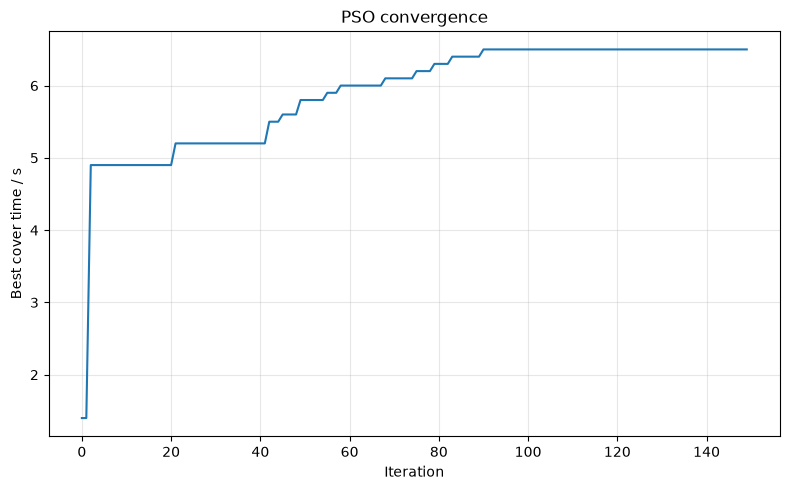

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 基本参数
# ============================================================

g = 9.8

R_SMOKE = 10.0
T_SMOKE = 20.0
V_SINK = 3.0

# M1
M0 = np.array([20000.0, 0.0, 2000.0])

v_M = -300.0 * M0 / np.linalg.norm(M0)

T_HIT = np.linalg.norm(M0) / 300.0

# FY1
FY1 = np.array([17800.0, 0.0, 1800.0])

# 烟幕弹自由落体到地面的最大时间
MAX_DELAY = np.sqrt(
    2 * FY1[2] / g
)


# ============================================================
# 2. 真目标表面采样
# ============================================================

def make_target_points(
    n_theta=36,
    n_z=3,
    n_r=1
):

    theta = np.linspace(
        0,
        2 * np.pi,
        n_theta,
        endpoint=False
    )

    points = []

    # --------------------------
    # 圆柱侧面
    # --------------------------

    for z in np.linspace(
        0,
        10,
        n_z
    ):

        x = 7 * np.cos(theta)

        y = (
            200
            + 7 * np.sin(theta)
        )

        z_arr = np.full(
            n_theta,
            z
        )

        points.append(
            np.column_stack(
                (x, y, z_arr)
            )
        )

    # --------------------------
    # 上下底面圆心
    # --------------------------

    points.append(
        np.array([
            [0.0, 200.0, 0.0],
            [0.0, 200.0, 10.0]
        ])
    )

    # --------------------------
    # 上下底面
    # --------------------------

    for z in [0.0, 10.0]:

        for r in np.linspace(
            7 / n_r,
            7,
            n_r
        ):

            x = (
                r
                * np.cos(theta)
            )

            y = (
                200
                + r * np.sin(theta)
            )

            z_arr = np.full(
                n_theta,
                z
            )

            points.append(
                np.column_stack(
                    (x, y, z_arr)
                )
            )

    return np.vstack(points)


# PSO 搜索阶段
TARGET_COARSE = make_target_points(
    n_theta=36,
    n_z=3,
    n_r=1
)

# 最终复算阶段
TARGET_FINE = make_target_points(
    n_theta=360,
    n_z=11,
    n_r=6
)


# ============================================================
# 3. PSO 搜索阶段时间网格
# ============================================================

DT_COARSE = 0.1

TIMES_COARSE = np.arange(
    0,
    T_HIT + 1e-12,
    DT_COARSE
)

# 预计算所有时刻 M1 位置
MISSILES_COARSE = (
    M0
    + TIMES_COARSE[:, None]
    * v_M
)

# 预计算 M1 -> 所有目标采样点
MP_COARSE = (
    TARGET_COARSE[None, :, :]
    - MISSILES_COARSE[:, None, :]
)

MP2_COARSE = np.einsum(
    "tnk,tnk->tn",
    MP_COARSE,
    MP_COARSE
)


# ============================================================
# 4. PSO变量解码
# ============================================================

def decode_variables(x):
    """
    PSO内部变量：

    x = [
        theta,
        speed,
        u1,
        u2,
        u3,
        q1,
        q2,
        q3
    ]

    theta : 无人机航向
    speed : 无人机速度

    u1,u2,u3 ∈ [0,1]
    用于生成三个投弹时刻

    q1,q2,q3 ∈ [0,1]
    用于生成三个起爆延迟

    这种参数化自动满足：
        t2 - t1 >= 1
        t3 - t2 >= 1
    """

    theta = x[0]
    speed = x[1]

    u1, u2, u3 = x[2:5]

    q = np.array(
        x[5:8]
    )

    # ========================================================
    # 三次投弹时刻
    # ========================================================

    # 给两个至少1s的间隔预留2s
    total_slack = (
        T_HIT - 2
    )

    # 第一枚
    t1 = (
        u1
        * total_slack
    )

    # 第二枚
    remaining2 = max(
        T_HIT
        - t1
        - 2,
        0
    )

    t2 = (
        t1
        + 1
        + u2 * remaining2
    )

    # 第三枚
    remaining3 = max(
        T_HIT
        - t2
        - 1,
        0
    )

    t3 = (
        t2
        + 1
        + u3 * remaining3
    )

    t_drop = np.array([
        t1,
        t2,
        t3
    ])

    # ========================================================
    # 起爆延迟
    # ========================================================

    # 起爆延迟不能超过：
    #
    # 1. 烟幕弹自由落体到地面的时间
    # 2. M1 到达假目标的剩余时间

    max_delay = np.minimum(
        MAX_DELAY,
        np.maximum(
            T_HIT - t_drop,
            0
        )
    )

    delay = (
        q * max_delay
    )

    return (
        theta,
        speed,
        t_drop,
        delay
    )


# ============================================================
# 5. 三枚烟幕弹的运动参数
# ============================================================

def calculate_smoke_parameters(
    theta,
    speed,
    t_drop,
    delay
):

    direction = np.array([
        np.cos(theta),
        np.sin(theta),
        0.0
    ])

    velocity = (
        speed * direction
    )

    # --------------------------
    # 投弹点
    # --------------------------

    P_drop = (
        FY1[None, :]
        + t_drop[:, None]
        * velocity
    )

    # --------------------------
    # 起爆时刻
    # --------------------------

    t_explode = (
        t_drop
        + delay
    )

    # --------------------------
    # 起爆点
    # --------------------------

    P_explode = (
        FY1[None, :]
        + t_explode[:, None]
        * velocity
    )

    P_explode = (
        P_explode.copy()
    )

    # 自由落体
    P_explode[:, 2] -= (
        0.5
        * g
        * delay**2
    )

    return (
        velocity,
        P_drop,
        t_explode,
        P_explode
    )


# ============================================================
# 6. 粗网格联合遮蔽计算
# ============================================================

def evaluate_strategy(
    x,
    return_details=False
):

    (
        theta,
        speed,
        t_drop,
        delay

    ) = decode_variables(x)

    (
        velocity,
        P_drop,
        t_explode,
        P_explode

    ) = calculate_smoke_parameters(
        theta,
        speed,
        t_drop,
        delay
    )

    T = len(
        TIMES_COARSE
    )

    N = len(
        TARGET_COARSE
    )

    # best_distance2[t,j]
    #
    # 表示：
    # 在时刻t，对于第j个目标点，
    # 三枚烟幕中距离该视线最近的距离平方

    best_distance2 = np.full(
        (T, N),
        np.inf
    )

    # ========================================================
    # 三枚烟幕分别计算
    # ========================================================

    for k in range(3):

        te = (
            t_explode[k]
        )

        Pe = (
            P_explode[k]
        )

        # 当前烟幕有效的时刻
        active = (
            (TIMES_COARSE >= te)
            &
            (
                TIMES_COARSE
                <= min(
                    te + T_SMOKE,
                    T_HIT
                )
            )
        )

        idx = np.flatnonzero(
            active
        )

        if len(idx) == 0:
            continue

        # ----------------------
        # 烟幕中心
        # ----------------------

        C = np.repeat(
            Pe[None, :],
            len(idx),
            axis=0
        )

        C[:, 2] -= (
            V_SINK
            * (
                TIMES_COARSE[idx]
                - te
            )
        )

        # ----------------------
        # 导弹 -> 烟幕中心
        # ----------------------

        MC = (
            C
            - MISSILES_COARSE[idx]
        )

        # ----------------------
        # 投影
        # ----------------------

        dot = np.einsum(
            "tnk,tk->tn",
            MP_COARSE[idx],
            MC
        )

        lam = (
            dot
            / MP2_COARSE[idx]
        )

        lam = np.clip(
            lam,
            0.0,
            1.0
        )

        MC2 = np.einsum(
            "tk,tk->t",
            MC,
            MC
        )[:, None]

        # ----------------------
        # 点到线段距离平方
        # ----------------------

        d2 = (
            MC2
            - 2 * lam * dot
            + lam**2
            * MP2_COARSE[idx]
        )

        d2 = np.maximum(
            d2,
            0
        )

        # ====================================================
        # 对三枚烟幕取最小值
        #
        # min_k d_kj(t)
        # ====================================================

        best_distance2[idx] = np.minimum(
            best_distance2[idx],
            d2
        )

    # ========================================================
    # 对所有目标点取最大值
    #
    # D(t)^2 =
    #
    # max_j min_k d_kj(t)^2
    # ========================================================

    D2 = np.max(
        best_distance2,
        axis=1
    )

    # ========================================================
    # 有效遮蔽
    # ========================================================

    covered = (
        D2
        <= R_SMOKE**2
    )

    cover_time = (
        np.count_nonzero(
            covered
        )
        * DT_COARSE
    )

    # ========================================================
    # 辅助指标
    # ========================================================

    finite = np.isfinite(
        D2
    )

    if np.any(finite):

        min_D = np.sqrt(
            np.min(
                D2[finite]
            )
        )

    else:

        min_D = 1e6

    # ========================================================
    # PSO最大化score
    #
    # 主要目标：
    #   最大化 cover_time
    #
    # 次要目标：
    #   若两个方案遮蔽时间相同，
    #   选择距离有效区域更深的方案
    # ========================================================

    score = (
        1e6 * cover_time
        - min_D
    )

    if return_details:

        return {
            "score": score,
            "cover_time": cover_time,
            "theta": theta,
            "speed": speed,
            "t_drop": t_drop,
            "delay": delay,
            "t_explode": t_explode,
            "P_drop": P_drop,
            "P_explode": P_explode,
            "covered": covered,
            "D": np.sqrt(D2)
        }

    return score


# ============================================================
# 7. 第一问方案作为PSO初始参考解
# ============================================================

def make_initial_solution():

    theta = np.pi

    speed = 120.0

    # 三枚依次投放
    t1 = 1.5

    u1 = (
        t1
        / (T_HIT - 2)
    )

    # 第二、第三枚均取最小1s间隔
    u2 = 0.0
    u3 = 0.0

    # 延迟3.6s
    q = (
        3.6
        / MAX_DELAY
    )

    return np.array([
        theta,
        speed,
        u1,
        u2,
        u3,
        q,
        q,
        q
    ])


X0 = make_initial_solution()


# ============================================================
# 8. 粒子群优化
# ============================================================

def run_pso(
    seed=42,
    n_particles=40,
    n_iterations=150
):

    rng = np.random.default_rng(
        seed
    )

    # ========================================================
    # 变量边界
    # ========================================================

    lower = np.array([
        0.0,
        70.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0
    ])

    upper = np.array([
        2 * np.pi,
        140.0,
        1.0,
        1.0,
        1.0,
        1.0,
        1.0,
        1.0
    ])

    ranges = (
        upper - lower
    )

    # ========================================================
    # 初始化粒子
    # ========================================================

    X = rng.uniform(
        lower,
        upper,
        size=(
            n_particles,
            8
        )
    )

    # 第一只粒子使用已知可行方案
    X[0] = X0

    # 在已知方案附近加入若干粒子
    for i in range(
        1,
        min(8, n_particles)
    ):

        perturb = np.array([
            rng.normal(0, 0.20),
            rng.normal(0, 10.0),
            rng.normal(0, 0.03),
            rng.normal(0, 0.03),
            rng.normal(0, 0.03),
            rng.normal(0, 0.08),
            rng.normal(0, 0.08),
            rng.normal(0, 0.08)
        ])

        X[i] = (
            X0 + perturb
        )

        X[i] = np.clip(
            X[i],
            lower,
            upper
        )

        X[i, 0] %= (
            2 * np.pi
        )

    # ========================================================
    # 粒子速度初始化
    # ========================================================

    V = rng.uniform(
        -0.08 * ranges,
        0.08 * ranges,
        size=X.shape
    )

    # ========================================================
    # PSO参数
    # ========================================================

    c1 = 1.7
    c2 = 1.7

    vmax = (
        0.15 * ranges
    )

    # ========================================================
    # 初始适应度
    # ========================================================

    scores = np.array([
        evaluate_strategy(x)
        for x in X
    ])

    # 个体最优
    pbest = X.copy()

    pbest_score = (
        scores.copy()
    )

    # 全局最优
    index = np.argmax(
        scores
    )

    gbest = (
        X[index].copy()
    )

    gbest_score = (
        scores[index]
    )

    history = []

    # ========================================================
    # PSO迭代
    # ========================================================

    for iteration in range(
        n_iterations
    ):

        # ----------------------
        # 惯性权重线性递减
        # ----------------------

        w = (
            0.9
            - 0.5
            * iteration
            / max(
                n_iterations - 1,
                1
            )
        )

        r1 = rng.random(
            X.shape
        )

        r2 = rng.random(
            X.shape
        )

        # ----------------------
        # 更新粒子速度
        # ----------------------

        V = (
            w * V

            + c1
            * r1
            * (
                pbest - X
            )

            + c2
            * r2
            * (
                gbest - X
            )
        )

        V = np.clip(
            V,
            -vmax,
            vmax
        )

        # ----------------------
        # 更新粒子位置
        # ----------------------

        X = (
            X + V
        )

        # 航向角周期处理
        X[:, 0] %= (
            2 * np.pi
        )

        # 其他变量边界处理
        X[:, 1:] = np.clip(
            X[:, 1:],
            lower[1:],
            upper[1:]
        )

        # ----------------------
        # 重新评价
        # ----------------------

        scores = np.array([
            evaluate_strategy(x)
            for x in X
        ])

        # ----------------------
        # 更新个体最优
        # ----------------------

        better = (
            scores
            > pbest_score
        )

        pbest[better] = (
            X[better]
        )

        pbest_score[better] = (
            scores[better]
        )

        # ----------------------
        # 更新全局最优
        # ----------------------

        index = np.argmax(
            scores
        )

        if (
            scores[index]
            > gbest_score
        ):

            gbest_score = (
                scores[index]
            )

            gbest = (
                X[index].copy()
            )

        detail = evaluate_strategy(
            gbest,
            return_details=True
        )

        history.append(
            detail[
                "cover_time"
            ]
        )

        if (
            iteration % 10 == 0
            or
            iteration
            == n_iterations - 1
        ):

            print(
                f"迭代 {iteration:3d} | "
                f"当前最优 "
                f"{detail['cover_time']:.3f} s"
            )

    return (
        gbest,
        gbest_score,
        history
    )


# ============================================================
# 9. 多次独立运行PSO
# ============================================================

def multi_start_pso():

    seeds = [
        1,
        7,
        19,
        42,
        123
    ]

    best_x = None

    best_score = -np.inf

    best_history = None

    for seed in seeds:

        print()
        print(
            "=" * 60
        )

        print(
            f"PSO seed = {seed}"
        )

        print(
            "=" * 60
        )

        (
            x,
            score,
            history

        ) = run_pso(
            seed=seed,
            n_particles=40,
            n_iterations=150
        )

        detail = evaluate_strategy(
            x,
            return_details=True
        )

        print(
            f"本次最优遮蔽时间 = "
            f"{detail['cover_time']:.3f} s"
        )

        if score > best_score:

            best_score = score

            best_x = x.copy()

            best_history = (
                history.copy()
            )

    return (
        best_x,
        best_history
    )


# ============================================================
# 10. 高精度复算
# ============================================================

def evaluate_fine(
    x,
    dt=0.005,
    target_points=TARGET_FINE,
    chunk_size=32
):

    (
        theta,
        speed,
        t_drop,
        delay

    ) = decode_variables(x)

    (
        velocity,
        P_drop,
        t_explode,
        P_explode

    ) = calculate_smoke_parameters(
        theta,
        speed,
        t_drop,
        delay
    )

    # 只扫描可能存在有效烟幕的时间
    t_start = np.min(
        t_explode
    )

    t_end = min(
        np.max(
            t_explode
            + T_SMOKE
        ),
        T_HIT
    )

    times = np.arange(
        t_start,
        t_end + 0.5 * dt,
        dt
    )

    covered = np.zeros(
        len(times),
        dtype=bool
    )

    D = np.full(
        len(times),
        np.inf
    )

    # ========================================================
    # 分块计算
    # ========================================================

    for start in range(
        0,
        len(times),
        chunk_size
    ):

        end = min(
            start + chunk_size,
            len(times)
        )

        tc = (
            times[start:end]
        )

        # 当前导弹位置
        M = (
            M0
            + tc[:, None]
            * v_M
        )

        # 导弹 -> 所有目标点
        MP = (
            target_points[None, :, :]
            - M[:, None, :]
        )

        MP2 = np.einsum(
            "tnk,tnk->tn",
            MP,
            MP
        )

        # 三枚烟幕中
        # 每条视线的最小距离
        best_d2 = np.full(
            (
                len(tc),
                len(target_points)
            ),
            np.inf
        )

        for k in range(3):

            te = (
                t_explode[k]
            )

            Pe = (
                P_explode[k]
            )

            active = (
                (tc >= te)
                &
                (
                    tc
                    <= te + T_SMOKE
                )
            )

            idx = np.flatnonzero(
                active
            )

            if len(idx) == 0:
                continue

            # 烟幕中心
            C = np.repeat(
                Pe[None, :],
                len(idx),
                axis=0
            )

            C[:, 2] -= (
                V_SINK
                * (
                    tc[idx]
                    - te
                )
            )

            # M -> C
            MC = (
                C
                - M[idx]
            )

            dot = np.einsum(
                "tnk,tk->tn",
                MP[idx],
                MC
            )

            lam = np.clip(
                dot
                / MP2[idx],
                0.0,
                1.0
            )

            MC2 = np.einsum(
                "tk,tk->t",
                MC,
                MC
            )[:, None]

            d2 = (
                MC2
                - 2 * lam * dot
                + lam**2
                * MP2[idx]
            )

            d2 = np.maximum(
                d2,
                0.0
            )

            # 对烟幕取min
            best_d2[idx] = np.minimum(
                best_d2[idx],
                d2
            )

        # 对目标点取max
        D2 = np.max(
            best_d2,
            axis=1
        )

        D[start:end] = np.sqrt(
            D2
        )

        covered[start:end] = (
            D2
            <= R_SMOKE**2
        )

    cover_time = (
        np.count_nonzero(
            covered
        )
        * dt
    )

    return {
        "theta": theta,
        "speed": speed,
        "t_drop": t_drop,
        "delay": delay,
        "t_explode": t_explode,
        "P_drop": P_drop,
        "P_explode": P_explode,
        "times": times,
        "D": D,
        "covered": covered,
        "cover_time": cover_time
    }


# ============================================================
# 11. 找出所有有效遮蔽区间
# ============================================================

def find_intervals(
    times,
    covered
):

    intervals = []

    start = None

    for i in range(
        len(times)
    ):

        if (
            covered[i]
            and start is None
        ):

            start = (
                times[i]
            )

        if (
            start is not None
            and (
                i
                == len(times) - 1
                or
                not covered[i + 1]
            )
        ):

            end = (
                times[i]
            )

            intervals.append(
                (start, end)
            )

            start = None

    return intervals


# ============================================================
# 12. 主程序
# ============================================================

if __name__ == "__main__":

    print(
        f"M1到达假目标时间 = "
        f"{T_HIT:.6f} s"
    )

    print(
        f"粗网格目标点数 = "
        f"{len(TARGET_COARSE)}"
    )

    print(
        f"精细网格目标点数 = "
        f"{len(TARGET_FINE)}"
    )

    # ========================================================
    # PSO全局搜索
    # ========================================================

    (
        best_x,
        history

    ) = multi_start_pso()

    # ========================================================
    # 高精度复算
    # ========================================================

    final = evaluate_fine(
        best_x,
        dt=0.005,
        target_points=TARGET_FINE
    )

    print()
    print(
        "=" * 60
    )

    print(
        "第三问 PSO 最优结果"
    )

    print(
        "=" * 60
    )

    print(
        f"FY1航向角 = "
        f"{final['theta']:.8f} rad"
    )

    print(
        f"FY1航向角 = "
        f"{np.degrees(final['theta']):.6f}°"
    )

    print(
        f"FY1速度 = "
        f"{final['speed']:.6f} m/s"
    )

    direction = np.array([
        np.cos(final["theta"]),
        np.sin(final["theta"]),
        0.0
    ])

    print(
        "航向单位向量 =",
        direction
    )

    print()

    # ========================================================
    # 输出三枚烟幕弹策略
    # ========================================================

    for k in range(3):

        print(
            f"---------- 烟幕弹{k + 1} ----------"
        )

        print(
            f"投弹时刻 = "
            f"{final['t_drop'][k]:.6f} s"
        )

        print(
            f"起爆延迟 = "
            f"{final['delay'][k]:.6f} s"
        )

        print(
            f"起爆时刻 = "
            f"{final['t_explode'][k]:.6f} s"
        )

        print(
            "投弹点 =",
            final["P_drop"][k]
        )

        print(
            "起爆点 =",
            final["P_explode"][k]
        )

        print()

    # ========================================================
    # 总有效遮蔽时间
    # ========================================================

    print(
        "=" * 60
    )

    print(
        f"总有效遮蔽时间 = "
        f"{final['cover_time']:.6f} s"
    )

    # ========================================================
    # 有效区间
    # ========================================================

    intervals = find_intervals(
        final["times"],
        final["covered"]
    )

    print(
        "\n有效遮蔽区间："
    )

    for i, (a, b) in enumerate(
        intervals,
        start=1
    ):

        print(
            f"区间{i}: "
            f"[{a:.6f}, {b:.6f}] s"
        )

    # ========================================================
    # PSO收敛曲线
    # ========================================================

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        history
    )

    plt.xlabel(
        "Iteration"
    )

    plt.ylabel(
        "Best cover time / s"
    )

    plt.title(
        "PSO convergence"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

M1到达假目标时间 = 66.999171 s
全局网格目标点数 = 182
局部网格目标点数 = 422
验证网格目标点数 = 2702
最终网格目标点数 = 8282

全局 PSO | seed = 1
初始最优 = 1.400 s
迭代  10 | 当前最优 4.200 s
迭代  20 | 当前最优 4.200 s
迭代  30 | 当前最优 5.400 s
迭代  40 | 当前最优 5.600 s
迭代  50 | 当前最优 5.600 s
迭代  60 | 当前最优 5.900 s
迭代  70 | 当前最优 6.200 s
迭代  80 | 当前最优 6.200 s
迭代  90 | 当前最优 6.300 s
迭代 100 | 当前最优 6.400 s
迭代 110 | 当前最优 6.700 s
迭代 120 | 当前最优 7.200 s
迭代 130 | 当前最优 7.300 s
迭代 140 | 当前最优 7.300 s
迭代 150 | 当前最优 7.300 s
迭代 156 | 发生停滞，重启 12 个粒子
迭代 160 | 当前最优 7.300 s
迭代 170 | 当前最优 7.300 s
迭代 180 | 当前最优 7.300 s
本次最终结果 = 7.300 s

全局 PSO | seed = 7
初始最优 = 1.400 s
迭代  10 | 当前最优 3.800 s
迭代  20 | 当前最优 4.400 s
迭代  30 | 当前最优 4.400 s
迭代  40 | 当前最优 4.400 s
迭代  50 | 当前最优 4.700 s
迭代  60 | 当前最优 5.300 s
迭代  70 | 当前最优 6.400 s
迭代  80 | 当前最优 6.400 s
迭代  90 | 当前最优 6.600 s
迭代 100 | 当前最优 6.700 s
迭代 110 | 当前最优 7.400 s
迭代 120 | 当前最优 7.500 s
迭代 130 | 当前最优 7.600 s
迭代 140 | 当前最优 7.700 s
迭代 150 | 当前最优 7.700 s
迭代 160 | 当前最优 7.700 s
迭代 163 | 发生停滞，重启 12 个粒子
迭代 170 | 当前最优 7.700 s
迭代 180 | 当前

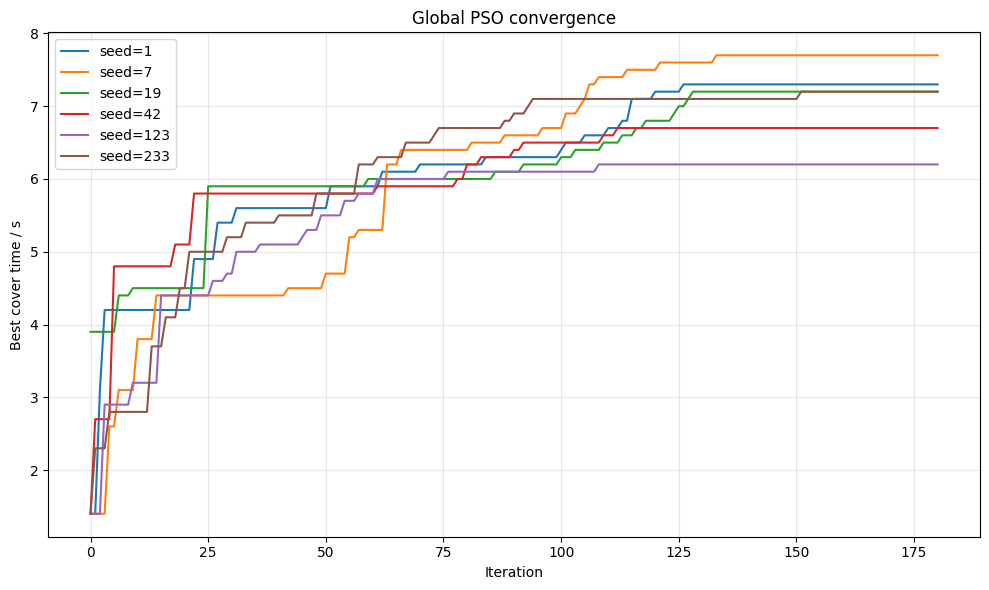


局部精修 1/3
来源 seed = 7
初始最优 = 7.550 s
迭代  10 | 当前最优 7.550 s
迭代  20 | 当前最优 7.550 s
迭代  30 | 发生停滞，重启 8 个粒子
迭代  30 | 当前最优 7.550 s
迭代  40 | 当前最优 7.550 s
迭代  50 | 当前最优 7.550 s
迭代  60 | 当前最优 7.600 s
迭代  70 | 当前最优 7.600 s
迭代  80 | 当前最优 7.600 s
迭代  82 | 发生停滞，重启 8 个粒子
迭代  90 | 当前最优 7.600 s
迭代 100 | 当前最优 7.600 s

局部精修 2/3
来源 seed = 1
初始最优 = 7.200 s
迭代  10 | 当前最优 7.200 s
迭代  20 | 当前最优 7.200 s
迭代  30 | 发生停滞，重启 8 个粒子
迭代  30 | 当前最优 7.200 s
迭代  40 | 当前最优 7.200 s
迭代  50 | 当前最优 7.200 s
迭代  60 | 当前最优 7.250 s
迭代  70 | 当前最优 7.250 s
迭代  80 | 当前最优 7.300 s
迭代  90 | 当前最优 7.300 s
迭代 100 | 当前最优 7.300 s

局部精修 3/3
来源 seed = 19
初始最优 = 7.100 s
迭代  10 | 当前最优 7.100 s
迭代  20 | 当前最优 7.100 s
迭代  30 | 发生停滞，重启 8 个粒子
迭代  30 | 当前最优 7.100 s
迭代  40 | 当前最优 7.150 s
迭代  50 | 当前最优 7.150 s
迭代  60 | 当前最优 7.200 s
迭代  70 | 当前最优 7.200 s
迭代  80 | 当前最优 7.200 s
迭代  81 | 发生停滞，重启 8 个粒子
迭代  90 | 当前最优 7.200 s
迭代 100 | 当前最优 7.200 s

候选方案高精度复算
候选 1 | 来源 seed=  7 | T=7.490697 s
候选 2 | 来源 seed=  1 | T=7.235802 s
候选 3 | 来源 seed= 19 | T=7.103265 s


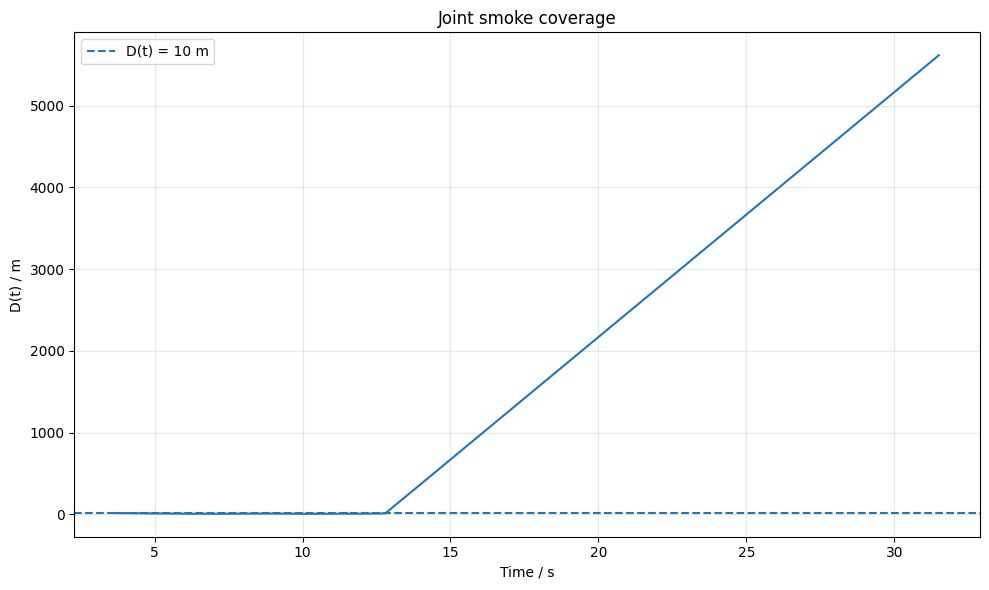

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv

# ============================================================
# 0. PSO计算参数
# ============================================================

# ---------- 第一阶段：全局搜索 ----------
GLOBAL_SEEDS = [1, 7, 19, 42, 123, 233]
GLOBAL_PARTICLES = 50
GLOBAL_ITERATIONS = 180

# 搜索阶段时间步长
DT_GLOBAL = 0.1

# ---------- 第二阶段：局部精修 ----------
TOP_K = 3
LOCAL_PARTICLES = 35
LOCAL_ITERATIONS = 100
DT_LOCAL = 0.05

# ---------- 最终验证 ----------
DT_VERIFY = 0.005
DT_FINAL = 0.002

# 停滞多少代后重启部分粒子
STAGNATION_PATIENCE = 30

# 每次重启多少比例
RESTART_FRACTION = 0.25

# 终端每多少代打印一次
# 若希望看到“每一代”的最优值，改成 1
PRINT_EVERY = 10


# ============================================================
# 1. 基本物理参数
# ============================================================

g = 9.8

R_SMOKE = 10.0
T_SMOKE = 20.0
V_SINK = 3.0

# M1初始位置
M0 = np.array([
    20000.0,
    0.0,
    2000.0
])

# M1以300m/s飞向假目标原点
v_M = (
    -300.0
    * M0
    / np.linalg.norm(M0)
)

# M1到达假目标的时间
T_HIT = (
    np.linalg.norm(M0)
    / 300.0
)

# FY1初始位置
FY1 = np.array([
    17800.0,
    0.0,
    1800.0
])

# 烟幕弹自由落体到地面的最大时间
MAX_DELAY = np.sqrt(
    2 * FY1[2] / g
)


# ============================================================
# 2. 圆柱目标表面采样
# ============================================================

def make_target_points(
    n_theta,
    n_z,
    n_r
):
    theta = np.linspace(
        0,
        2 * np.pi,
        n_theta,
        endpoint=False
    )

    points = []

    # --------------------------------------------------------
    # 圆柱侧面
    # --------------------------------------------------------

    for z in np.linspace(
        0,
        10,
        n_z
    ):

        x = (
            7
            * np.cos(theta)
        )

        y = (
            200
            + 7 * np.sin(theta)
        )

        z_array = np.full(
            n_theta,
            z
        )

        points.append(
            np.column_stack(
                (
                    x,
                    y,
                    z_array
                )
            )
        )

    # --------------------------------------------------------
    # 上下底面圆心
    # --------------------------------------------------------

    points.append(
        np.array([
            [0.0, 200.0, 0.0],
            [0.0, 200.0, 10.0]
        ])
    )

    # --------------------------------------------------------
    # 上下底面
    # --------------------------------------------------------

    for z in [0.0, 10.0]:

        for r in np.linspace(
            7 / n_r,
            7,
            n_r
        ):

            x = (
                r
                * np.cos(theta)
            )

            y = (
                200
                + r * np.sin(theta)
            )

            z_array = np.full(
                n_theta,
                z
            )

            points.append(
                np.column_stack(
                    (
                        x,
                        y,
                        z_array
                    )
                )
            )

    return np.vstack(points)


# 第一阶段：粗网格
TARGET_GLOBAL = make_target_points(
    n_theta=36,
    n_z=3,
    n_r=1
)

# 第二阶段：中等网格
TARGET_LOCAL = make_target_points(
    n_theta=60,
    n_z=3,
    n_r=2
)

# 候选方案验证
TARGET_VERIFY = make_target_points(
    n_theta=180,
    n_z=7,
    n_r=4
)

# 最终高精度计算
TARGET_FINE = make_target_points(
    n_theta=360,
    n_z=11,
    n_r=6
)


# ============================================================
# 3. 建立搜索缓存
#
# 将与粒子参数无关的导弹位置和目标视线提前计算
# ============================================================

def build_cache(
    target_points,
    dt
):
    times = np.arange(
        0,
        T_HIT + 0.5 * dt,
        dt
    )

    missiles = (
        M0
        + times[:, None]
        * v_M
    )

    # M(t) -> 所有目标点
    MP = (
        target_points[
            None,
            :,
            :
        ]
        - missiles[
            :,
            None,
            :
        ]
    )

    MP2 = np.einsum(
        "tnk,tnk->tn",
        MP,
        MP
    )

    return {
        "times": times,
        "missiles": missiles,
        "MP": MP,
        "MP2": MP2,
        "target_points": target_points,
        "dt": dt
    }


# ============================================================
# 4. PSO变量编码
#
# x =
# [
#     theta,
#     speed,
#     u1,u2,u3,
#     q1,q2,q3
# ]
# ============================================================

def decode_variables(x):

    theta = x[0]
    speed = x[1]

    u1 = x[2]
    u2 = x[3]
    u3 = x[4]

    q = np.array(
        x[5:8]
    )

    # --------------------------------------------------------
    # 三个投弹时刻
    #
    # 自动保证：
    #
    # t2-t1 >= 1
    # t3-t2 >= 1
    # --------------------------------------------------------

    t1 = (
        u1
        * (T_HIT - 2)
    )

    remaining2 = max(
        T_HIT
        - t1
        - 2,
        0
    )

    t2 = (
        t1
        + 1
        + u2
        * remaining2
    )

    remaining3 = max(
        T_HIT
        - t2
        - 1,
        0
    )

    t3 = (
        t2
        + 1
        + u3
        * remaining3
    )

    t_drop = np.array([
        t1,
        t2,
        t3
    ])

    # --------------------------------------------------------
    # 起爆延迟
    # --------------------------------------------------------

    max_delay = np.minimum(
        MAX_DELAY,
        np.maximum(
            T_HIT
            - t_drop,
            0
        )
    )

    delay = (
        q
        * max_delay
    )

    return (
        theta,
        speed,
        t_drop,
        delay
    )


# ============================================================
# 5. 三枚烟幕弹运动参数
# ============================================================

def calculate_smoke_parameters(
    theta,
    speed,
    t_drop,
    delay
):

    direction = np.array([
        np.cos(theta),
        np.sin(theta),
        0.0
    ])

    velocity = (
        speed
        * direction
    )

    # 投弹点
    P_drop = (
        FY1[None, :]
        + t_drop[:, None]
        * velocity
    )

    # 起爆时刻
    t_explode = (
        t_drop
        + delay
    )

    # 起爆点
    P_explode = (
        FY1[None, :]
        + t_explode[:, None]
        * velocity
    )

    P_explode = (
        P_explode.copy()
    )

    # 自由落体
    P_explode[:, 2] -= (
        0.5
        * g
        * delay**2
    )

    return {
        "direction": direction,
        "velocity": velocity,
        "P_drop": P_drop,
        "P_explode": P_explode,
        "t_explode": t_explode
    }


# ============================================================
# 6. 搜索阶段联合遮蔽计算
#
# D(t) = max_j min_k d_kj(t)
# ============================================================

def evaluate_cached(
    x,
    cache,
    return_details=False
):

    (
        theta,
        speed,
        t_drop,
        delay
    ) = decode_variables(x)

    smoke = calculate_smoke_parameters(
        theta,
        speed,
        t_drop,
        delay
    )

    t_explode = (
        smoke["t_explode"]
    )

    P_explode = (
        smoke["P_explode"]
    )

    times = cache["times"]

    # --------------------------------------------------------
    # 只计算至少存在一个烟幕的时刻
    # --------------------------------------------------------

    any_active = np.zeros(
        len(times),
        dtype=bool
    )

    for k in range(3):

        any_active |= (
            (times >= t_explode[k])
            &
            (
                times
                <= t_explode[k]
                + T_SMOKE
            )
        )

    eval_idx = np.flatnonzero(
        any_active
    )

    if len(eval_idx) == 0:

        if return_details:
            return None

        return (
            -1e10,
            0.0
        )

    teval = (
        times[eval_idx]
    )

    missiles = (
        cache["missiles"][eval_idx]
    )

    MP = (
        cache["MP"][eval_idx]
    )

    MP2 = (
        cache["MP2"][eval_idx]
    )

    n_time = len(teval)

    n_target = len(
        cache["target_points"]
    )

    # --------------------------------------------------------
    # best_d2[t,j]
    #
    # = min_k d_kj(t)^2
    # --------------------------------------------------------

    best_d2 = np.full(
        (
            n_time,
            n_target
        ),
        np.inf
    )

    # ========================================================
    # 三枚烟幕
    # ========================================================

    for k in range(3):

        te = (
            t_explode[k]
        )

        Pe = (
            P_explode[k]
        )

        active = (
            (teval >= te)
            &
            (
                teval
                <= te + T_SMOKE
            )
        )

        idx = np.flatnonzero(
            active
        )

        if len(idx) == 0:
            continue

        # ----------------------------------------------------
        # 当前烟幕中心
        # ----------------------------------------------------

        C = np.repeat(
            Pe[None, :],
            len(idx),
            axis=0
        )

        C[:, 2] -= (
            V_SINK
            * (
                teval[idx]
                - te
            )
        )

        # M -> C
        MC = (
            C
            - missiles[idx]
        )

        dot = np.einsum(
            "tnk,tk->tn",
            MP[idx],
            MC
        )

        lam = (
            dot
            / MP2[idx]
        )

        lam = np.clip(
            lam,
            0.0,
            1.0
        )

        MC2 = np.einsum(
            "tk,tk->t",
            MC,
            MC
        )[:, None]

        d2 = (
            MC2
            - 2 * lam * dot
            + lam**2
            * MP2[idx]
        )

        d2 = np.maximum(
            d2,
            0.0
        )

        # ----------------------------------------------------
        # 对三枚烟幕取最小值
        # ----------------------------------------------------

        best_d2[idx] = np.minimum(
            best_d2[idx],
            d2
        )

    # --------------------------------------------------------
    # 对目标点取最大值
    # --------------------------------------------------------

    D2 = np.max(
        best_d2,
        axis=1
    )

    D = np.sqrt(
        D2
    )

    covered = (
        D
        <= R_SMOKE
    )

    cover_time = (
        np.count_nonzero(
            covered
        )
        * cache["dt"]
    )

    # ========================================================
    # 平滑辅助指标
    #
    # 用来解决大量粒子的cover_time完全相同的问题。
    #
    # proximity ∈ (0,1]
    #
    # 越接近D<=10，值越大。
    # ========================================================

    excess = np.maximum(
        D - R_SMOKE,
        0.0
    )

    proximity = np.mean(
        np.exp(
            -excess / 5.0
        )
    )

    # --------------------------------------------------------
    # 主目标仍然是遮蔽时间
    #
    # dt >= 0.05
    # 辅助项最大只有0.001，
    # 所以不会改变遮蔽时间的优先级
    # --------------------------------------------------------

    score = (
        cover_time
        + 1e-3
        * proximity
    )

    if return_details:

        covered_full = np.zeros(
            len(times),
            dtype=bool
        )

        D_full = np.full(
            len(times),
            np.inf
        )

        covered_full[eval_idx] = (
            covered
        )

        D_full[eval_idx] = D

        return {
            "score": score,
            "cover_time": cover_time,
            "theta": theta,
            "speed": speed,
            "t_drop": t_drop,
            "delay": delay,
            "t_explode": t_explode,
            "P_drop": smoke["P_drop"],
            "P_explode": smoke["P_explode"],
            "direction": smoke["direction"],
            "covered": covered_full,
            "D": D_full,
            "times": times
        }

    return (
        score,
        cover_time
    )


# ============================================================
# 7. 航向角周期差
#
# 359°和1°之间的距离应该是2°，而不是358°
# ============================================================

def angle_difference(
    target,
    current
):
    return (
        (
            target
            - current
            + np.pi
        )
        % (2 * np.pi)
        - np.pi
    )


# ============================================================
# 8. PSO变量边界
# ============================================================

LOWER = np.array([
    0.0,
    70.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0
])

UPPER = np.array([
    2 * np.pi,
    140.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0
])

RANGES = (
    UPPER - LOWER
)


# ============================================================
# 9. 边界处理
# ============================================================

def apply_bounds(
    X,
    V
):

    # 航向角周期处理
    X[:, 0] %= (
        2 * np.pi
    )

    # 其他变量
    for j in range(
        1,
        X.shape[1]
    ):

        below = (
            X[:, j]
            < LOWER[j]
        )

        above = (
            X[:, j]
            > UPPER[j]
        )

        # 撞边界后反弹
        V[below, j] *= -0.5
        V[above, j] *= -0.5

        X[:, j] = np.clip(
            X[:, j],
            LOWER[j],
            UPPER[j]
        )

    return X, V


# ============================================================
# 10. 已知可行初始方案
# ============================================================

def make_initial_solution():

    theta = np.pi
    speed = 120.0

    # 1.5,2.5,3.5s投弹
    u1 = (
        1.5
        / (T_HIT - 2)
    )

    u2 = 0.0
    u3 = 0.0

    q = (
        3.6
        / MAX_DELAY
    )

    return np.array([
        theta,
        speed,
        u1,
        u2,
        u3,
        q,
        q,
        q
    ])


X0 = make_initial_solution()


# ============================================================
# 11. 评价整个粒子群
# ============================================================

def evaluate_swarm(
    X,
    cache
):

    values = [
        evaluate_cached(
            x,
            cache
        )
        for x in X
    ]

    scores = np.array([
        item[0]
        for item in values
    ])

    cover_times = np.array([
        item[1]
        for item in values
    ])

    return (
        scores,
        cover_times
    )


# ============================================================
# 12. 单次PSO
# ============================================================

def run_pso(
    cache,
    seed,
    n_particles,
    n_iterations,
    center=None,
    local_mode=False
):

    rng = np.random.default_rng(
        seed
    )

    # --------------------------------------------------------
    # 初始化
    # --------------------------------------------------------

    X = rng.uniform(
        LOWER,
        UPPER,
        size=(
            n_particles,
            8
        )
    )

    if center is None:

        # 第一只粒子采用已知可行方案
        X[0] = X0

        # 在已知方案附近增加若干粒子
        n_near = min(
            10,
            n_particles
        )

        scale = np.array([
            0.03,
            0.10,
            0.03,
            0.03,
            0.03,
            0.08,
            0.08,
            0.08
        ])

        for i in range(
            1,
            n_near
        ):

            X[i] = (
                X0
                + rng.normal(
                    0,
                    1,
                    8
                )
                * scale
                * RANGES
            )

    else:

        # ====================================================
        # 局部精修阶段
        #
        # 75%粒子放在当前最好解附近
        # 25%仍全局随机，避免彻底丢失全局探索能力
        # ====================================================

        n_local = int(
            0.75
            * n_particles
        )

        scale = np.array([
            0.025,
            0.05,
            0.03,
            0.03,
            0.03,
            0.05,
            0.05,
            0.05
        ])

        X[:n_local] = (
            center
            + rng.normal(
                0,
                1,
                size=(
                    n_local,
                    8
                )
            )
            * scale
            * RANGES
        )

        X[0] = center.copy()

    # 初始速度
    V = rng.uniform(
        -0.05 * RANGES,
        0.05 * RANGES,
        size=X.shape
    )

    X, V = apply_bounds(
        X,
        V
    )

    # --------------------------------------------------------
    # 初始评价
    # --------------------------------------------------------

    (
        scores,
        cover_times
    ) = evaluate_swarm(
        X,
        cache
    )

    pbest = X.copy()

    pbest_score = (
        scores.copy()
    )

    index = np.argmax(
        scores
    )

    gbest = (
        X[index].copy()
    )

    gbest_score = (
        scores[index]
    )

    gbest_cover = (
        cover_times[index]
    )

    # --------------------------------------------------------
    # 历史最优
    # --------------------------------------------------------

    history = [
        gbest_cover
    ]

    # 停滞检测
    best_cover_seen = (
        gbest_cover
    )

    stagnation = 0
    restart_count = 0

    print(
        f"初始最优 = "
        f"{gbest_cover:.3f} s"
    )

    # ========================================================
    # PSO主循环
    # ========================================================

    for iteration in range(
        1,
        n_iterations + 1
    ):

        progress = (
            iteration
            / n_iterations
        )

        # ----------------------------------------------------
        # 动态惯性权重
        #
        # 前期探索：
        # w ≈ 0.9
        #
        # 后期收敛：
        # w ≈ 0.4
        # ----------------------------------------------------

        w = (
            0.9
            - 0.5
            * progress
        )

        # ----------------------------------------------------
        # 动态学习因子
        #
        # 前期更相信自身经验
        # 后期更相信群体最优
        # ----------------------------------------------------

        c1 = (
            2.5
            - 2.0
            * progress
        )

        c2 = (
            0.5
            + 2.0
            * progress
        )

        r1 = rng.random(
            X.shape
        )

        r2 = rng.random(
            X.shape
        )

        # ====================================================
        # 个体最优差
        # ====================================================

        diff_pbest = (
            pbest - X
        )

        # 航向角特殊处理
        diff_pbest[:, 0] = (
            angle_difference(
                pbest[:, 0],
                X[:, 0]
            )
        )

        # ====================================================
        # 全局最优差
        # ====================================================

        diff_gbest = (
            gbest[None, :]
            - X
        )

        diff_gbest[:, 0] = (
            angle_difference(
                gbest[0],
                X[:, 0]
            )
        )

        # ====================================================
        # 更新速度
        # ====================================================

        V = (
            w * V
            + c1
            * r1
            * diff_pbest
            + c2
            * r2
            * diff_gbest
        )

        # 限制最大速度
        vmax = (
            0.15
            * RANGES
        )

        V = np.clip(
            V,
            -vmax,
            vmax
        )

        # ====================================================
        # 更新位置
        # ====================================================

        X = (
            X + V
        )

        X, V = apply_bounds(
            X,
            V
        )

        # ====================================================
        # 重新计算适应度
        # ====================================================

        (
            scores,
            cover_times
        ) = evaluate_swarm(
            X,
            cache
        )

        # ====================================================
        # 更新个体最优
        # ====================================================

        better = (
            scores
            > pbest_score
        )

        pbest[better] = (
            X[better]
        )

        pbest_score[better] = (
            scores[better]
        )

        # ====================================================
        # 更新全局最优
        # ====================================================

        index = np.argmax(
            scores
        )

        if (
            scores[index]
            > gbest_score
        ):

            gbest_score = (
                scores[index]
            )

            gbest = (
                X[index].copy()
            )

            gbest_cover = (
                cover_times[index]
            )

        # ====================================================
        # 停滞判断
        # ====================================================

        if (
            gbest_cover
            > best_cover_seen
            + 0.5 * cache["dt"]
        ):

            best_cover_seen = (
                gbest_cover
            )

            stagnation = 0

        else:

            stagnation += 1

        # ====================================================
        # 长时间停滞 -> 重启部分粒子
        # ====================================================

        if (
            stagnation
            >= STAGNATION_PATIENCE
        ):

            n_restart = max(
                2,
                int(
                    RESTART_FRACTION
                    * n_particles
                )
            )

            # 表现最差的粒子
            worst = np.argsort(
                scores
            )[:n_restart]

            half = (
                n_restart // 2
            )

            global_idx = (
                worst[:half]
            )

            local_idx = (
                worst[half:]
            )

            # ----------------------------------------------
            # 一半重新全局随机
            # ----------------------------------------------

            if len(global_idx) > 0:

                X[global_idx] = (
                    rng.uniform(
                        LOWER,
                        UPPER,
                        size=(
                            len(global_idx),
                            8
                        )
                    )
                )

            # ----------------------------------------------
            # 一半在gbest附近重新生成
            # ----------------------------------------------

            if len(local_idx) > 0:

                restart_scale = np.array([
                    0.05,
                    0.10,
                    0.08,
                    0.08,
                    0.08,
                    0.10,
                    0.10,
                    0.10
                ])

                X[local_idx] = (
                    gbest
                    + rng.normal(
                        0,
                        1,
                        size=(
                            len(local_idx),
                            8
                        )
                    )
                    * restart_scale
                    * RANGES
                )

            V[worst] = (
                rng.uniform(
                    -0.05 * RANGES,
                    0.05 * RANGES,
                    size=(
                        n_restart,
                        8
                    )
                )
            )

            X, V = apply_bounds(
                X,
                V
            )

            # 重启粒子重新评价
            (
                new_scores,
                new_covers
            ) = evaluate_swarm(
                X[worst],
                cache
            )

            scores[worst] = (
                new_scores
            )

            cover_times[worst] = (
                new_covers
            )

            # 重置这些粒子的个人最优
            pbest[worst] = (
                X[worst]
            )

            pbest_score[worst] = (
                new_scores
            )

            # 检查重启后是否找到更好解
            index = np.argmax(
                scores
            )

            if (
                scores[index]
                > gbest_score
            ):

                gbest_score = (
                    scores[index]
                )

                gbest = (
                    X[index].copy()
                )

                gbest_cover = (
                    cover_times[index]
                )

            stagnation = 0

            restart_count += 1

            print(
                f"迭代 {iteration:3d} | "
                f"发生停滞，重启 "
                f"{n_restart} 个粒子"
            )

        # ====================================================
        # 保存每一代最优值
        # ====================================================

        history.append(
            gbest_cover
        )

        # ====================================================
        # 输出
        # ====================================================

        if (
            iteration % PRINT_EVERY == 0
            or iteration
            == n_iterations
        ):

            print(
                f"迭代 {iteration:3d} | "
                f"当前最优 "
                f"{gbest_cover:.3f} s"
            )

    return {
        "x": gbest,
        "score": gbest_score,
        "cover_time": gbest_cover,
        "history": np.array(history),
        "seed": seed,
        "restart_count": restart_count
    }


# ============================================================
# 13. 保存所有迭代历史
# ============================================================

def save_histories(
    runs,
    filename
):

    max_length = max(
        len(r["history"])
        for r in runs
    )

    with open(
        filename,
        "w",
        newline="",
        encoding="utf-8-sig"
    ) as f:

        writer = csv.writer(f)

        header = [
            "iteration"
        ]

        for r in runs:

            header.append(
                f"seed_{r['seed']}"
            )

        writer.writerow(
            header
        )

        for i in range(
            max_length
        ):

            row = [i]

            for r in runs:

                if i < len(
                    r["history"]
                ):

                    row.append(
                        r["history"][i]
                    )

                else:

                    row.append("")

            writer.writerow(
                row
            )


# ============================================================
# 14. 高精度联合遮蔽计算
# ============================================================

def evaluate_fine(
    x,
    target_points,
    dt,
    chunk_size=32
):

    (
        theta,
        speed,
        t_drop,
        delay
    ) = decode_variables(x)

    smoke = calculate_smoke_parameters(
        theta,
        speed,
        t_drop,
        delay
    )

    t_explode = (
        smoke["t_explode"]
    )

    P_explode = (
        smoke["P_explode"]
    )

    # --------------------------------------------------------
    # 时间范围
    # --------------------------------------------------------

    t_start = max(
        0.0,
        np.min(
            t_explode
        )
    )

    t_end = min(
        T_HIT,
        np.max(
            t_explode
            + T_SMOKE
        )
    )

    basic_times = np.arange(
        t_start,
        t_end + 0.5 * dt,
        dt
    )

    # 将每枚烟幕的起爆、失效时刻加入时间序列
    events = []

    for te in t_explode:

        events.append(
            te
        )

        events.append(
            min(
                te + T_SMOKE,
                T_HIT
            )
        )

    times = np.unique(
        np.concatenate(
            (
                basic_times,
                np.array(events)
            )
        )
    )

    D = np.full(
        len(times),
        np.inf
    )

    # ========================================================
    # 分块
    # ========================================================

    for start in range(
        0,
        len(times),
        chunk_size
    ):

        end = min(
            start + chunk_size,
            len(times)
        )

        tc = (
            times[start:end]
        )

        M = (
            M0
            + tc[:, None]
            * v_M
        )

        MP = (
            target_points[
                None,
                :,
                :
            ]
            - M[
                :,
                None,
                :
            ]
        )

        MP2 = np.einsum(
            "tnk,tnk->tn",
            MP,
            MP
        )

        best_d2 = np.full(
            (
                len(tc),
                len(target_points)
            ),
            np.inf
        )

        # ----------------------------------------------------
        # 三枚烟幕
        # ----------------------------------------------------

        for k in range(3):

            te = (
                t_explode[k]
            )

            Pe = (
                P_explode[k]
            )

            active = (
                (tc >= te)
                &
                (
                    tc
                    <= te + T_SMOKE
                )
            )

            idx = np.flatnonzero(
                active
            )

            if len(idx) == 0:
                continue

            C = np.repeat(
                Pe[None, :],
                len(idx),
                axis=0
            )

            C[:, 2] -= (
                V_SINK
                * (
                    tc[idx]
                    - te
                )
            )

            MC = (
                C
                - M[idx]
            )

            dot = np.einsum(
                "tnk,tk->tn",
                MP[idx],
                MC
            )

            lam = np.clip(
                dot
                / MP2[idx],
                0.0,
                1.0
            )

            MC2 = np.einsum(
                "tk,tk->t",
                MC,
                MC
            )[:, None]

            d2 = (
                MC2
                - 2 * lam * dot
                + lam**2
                * MP2[idx]
            )

            d2 = np.maximum(
                d2,
                0.0
            )

            best_d2[idx] = np.minimum(
                best_d2[idx],
                d2
            )

        D[start:end] = np.sqrt(
            np.max(
                best_d2,
                axis=1
            )
        )

    # --------------------------------------------------------
    # 利用D(t)=10的穿越点插值计算区间
    # --------------------------------------------------------

    intervals = find_intervals_precise(
        times,
        D
    )

    cover_time = sum(
        b - a
        for a, b in intervals
    )

    return {
        "theta": theta,
        "speed": speed,
        "t_drop": t_drop,
        "delay": delay,
        "t_explode": t_explode,
        "P_drop": smoke["P_drop"],
        "P_explode": smoke["P_explode"],
        "direction": smoke["direction"],
        "times": times,
        "D": D,
        "intervals": intervals,
        "cover_time": cover_time
    }


# ============================================================
# 15. 精确寻找D(t)=10的交界点
# ============================================================

def find_intervals_precise(
    times,
    D
):

    covered = (
        np.isfinite(D)
        &
        (
            D <= R_SMOKE
        )
    )

    intervals = []

    start_time = None

    # 如果第一个点已经有效
    if covered[0]:
        start_time = (
            times[0]
        )

    for i in range(
        len(times) - 1
    ):

        c0 = (
            covered[i]
        )

        c1 = (
            covered[i + 1]
        )

        # ====================================================
        # 无效 -> 有效
        # ====================================================

        if (
            not c0
            and c1
        ):

            # 两端都有限：
            # 线性插值D=10
            if (
                np.isfinite(D[i])
                and
                np.isfinite(D[i + 1])
            ):

                t0 = times[i]
                t1 = times[i + 1]

                d0 = D[i]
                d1 = D[i + 1]

                alpha = (
                    (R_SMOKE - d0)
                    / (d1 - d0)
                )

                start_time = (
                    t0
                    + alpha
                    * (t1 - t0)
                )

            else:

                # 烟幕瞬间起爆形成
                start_time = (
                    times[i + 1]
                )

        # ====================================================
        # 有效 -> 无效
        # ====================================================

        elif (
            c0
            and not c1
        ):

            if (
                np.isfinite(D[i])
                and
                np.isfinite(D[i + 1])
            ):

                t0 = times[i]
                t1 = times[i + 1]

                d0 = D[i]
                d1 = D[i + 1]

                alpha = (
                    (R_SMOKE - d0)
                    / (d1 - d0)
                )

                end_time = (
                    t0
                    + alpha
                    * (t1 - t0)
                )

            else:

                end_time = (
                    times[i]
                )

            if start_time is not None:

                intervals.append(
                    (
                        start_time,
                        end_time
                    )
                )

                start_time = None

    if (
        start_time is not None
        and covered[-1]
    ):

        intervals.append(
            (
                start_time,
                times[-1]
            )
        )

    return intervals


# ============================================================
# 16. 第一阶段：多次全局PSO
# ============================================================

def global_search():

    cache = build_cache(
        TARGET_GLOBAL,
        DT_GLOBAL
    )

    runs = []

    for seed in GLOBAL_SEEDS:

        print()
        print(
            "=" * 70
        )

        print(
            f"全局 PSO | seed = {seed}"
        )

        print(
            "=" * 70
        )

        result = run_pso(
            cache=cache,
            seed=seed,
            n_particles=GLOBAL_PARTICLES,
            n_iterations=GLOBAL_ITERATIONS
        )

        runs.append(
            result
        )

        print(
            f"本次最终结果 = "
            f"{result['cover_time']:.3f} s"
        )

    return runs


# ============================================================
# 17. 第二阶段：对最好的若干组解局部精修
# ============================================================

def local_refinement(
    global_runs
):

    # 按适应度排序
    sorted_runs = sorted(
        global_runs,
        key=lambda r: r["score"],
        reverse=True
    )

    candidates = (
        sorted_runs[:TOP_K]
    )

    cache = build_cache(
        TARGET_LOCAL,
        DT_LOCAL
    )

    local_runs = []

    for i, candidate in enumerate(
        candidates
    ):

        print()
        print(
            "=" * 70
        )

        print(
            f"局部精修 {i + 1}/{TOP_K}"
        )

        print(
            f"来源 seed = "
            f"{candidate['seed']}"
        )

        print(
            "=" * 70
        )

        result = run_pso(
            cache=cache,
            seed=10000
            + candidate["seed"],
            n_particles=LOCAL_PARTICLES,
            n_iterations=LOCAL_ITERATIONS,
            center=candidate["x"],
            local_mode=True
        )

        result[
            "source_seed"
        ] = candidate[
            "seed"
        ]

        local_runs.append(
            result
        )

    return local_runs


# ============================================================
# 18. 第三阶段：中高精度验证候选方案
# ============================================================

def verify_candidates(
    local_runs
):

    results = []

    print()
    print(
        "=" * 70
    )

    print(
        "候选方案高精度复算"
    )

    print(
        "=" * 70
    )

    for i, run in enumerate(
        local_runs
    ):

        detail = evaluate_fine(
            run["x"],
            target_points=TARGET_VERIFY,
            dt=DT_VERIFY,
            chunk_size=32
        )

        results.append({
            "x": run["x"],
            "detail": detail,
            "source_seed": run[
                "source_seed"
            ]
        })

        print(
            f"候选 {i + 1} | "
            f"来源 seed="
            f"{run['source_seed']:3d} | "
            f"T="
            f"{detail['cover_time']:.6f} s"
        )

    results.sort(
        key=lambda r:
        r["detail"]["cover_time"],
        reverse=True
    )

    return results


# ============================================================
# 19. 绘制多次PSO收敛曲线
# ============================================================

def plot_histories(
    runs,
    title
):

    plt.figure(
        figsize=(10, 6)
    )

    for run in runs:

        plt.plot(
            np.arange(
                len(
                    run["history"]
                )
            ),
            run["history"],
            label=(
                f"seed={run['seed']}"
            )
        )

    plt.xlabel(
        "Iteration"
    )

    plt.ylabel(
        "Best cover time / s"
    )

    plt.title(
        title
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 20. 主程序
# ============================================================

if __name__ == "__main__":

    print(
        f"M1到达假目标时间 = "
        f"{T_HIT:.6f} s"
    )

    print(
        f"全局网格目标点数 = "
        f"{len(TARGET_GLOBAL)}"
    )

    print(
        f"局部网格目标点数 = "
        f"{len(TARGET_LOCAL)}"
    )

    print(
        f"验证网格目标点数 = "
        f"{len(TARGET_VERIFY)}"
    )

    print(
        f"最终网格目标点数 = "
        f"{len(TARGET_FINE)}"
    )

    # ========================================================
    # 第一阶段
    # ========================================================

    global_runs = (
        global_search()
    )

    # --------------------------------------------------------
    # 保存每一代的最优值
    # --------------------------------------------------------

    save_histories(
        global_runs,
        "pso_global_history.csv"
    )

    # --------------------------------------------------------
    # 输出各次PSO最终结果
    # --------------------------------------------------------

    print()
    print(
        "=" * 70
    )

    print(
        "各次全局PSO最终结果"
    )

    print(
        "=" * 70
    )

    for run in sorted(
        global_runs,
        key=lambda r:
        r["cover_time"],
        reverse=True
    ):

        print(
            f"seed={run['seed']:3d} | "
            f"T={run['cover_time']:.3f} s | "
            f"重启次数="
            f"{run['restart_count']}"
        )

    # 收敛曲线
    plot_histories(
        global_runs,
        "Global PSO convergence"
    )

    # ========================================================
    # 第二阶段
    # ========================================================

    local_runs = (
        local_refinement(
            global_runs
        )
    )

    # ========================================================
    # 第三阶段
    # ========================================================

    verified = (
        verify_candidates(
            local_runs
        )
    )

    # 中高精度验证后的最好方案
    best_candidate = (
        verified[0]
    )

    # ========================================================
    # 第四阶段：最终高精度复算
    # ========================================================

    print()
    print(
        "=" * 70
    )

    print(
        "最终高精度复算"
    )

    print(
        "=" * 70
    )

    final = evaluate_fine(
        best_candidate["x"],
        target_points=TARGET_FINE,
        dt=DT_FINAL,
        chunk_size=16
    )

    # ========================================================
    # 最终输出
    # ========================================================

    print()
    print(
        "=" * 70
    )

    print(
        "第三问最终PSO方案"
    )

    print(
        "=" * 70
    )

    print(
        f"FY1航向角 = "
        f"{final['theta']:.10f} rad"
    )

    print(
        f"FY1航向角 = "
        f"{np.degrees(final['theta']):.8f}°"
    )

    print(
        f"FY1速度 = "
        f"{final['speed']:.8f} m/s"
    )

    print(
        "FY1航向单位向量 =",
        final["direction"]
    )

    print()

    for k in range(3):

        print(
            f"---------- 烟幕弹 {k + 1} ----------"
        )

        print(
            f"投弹时刻 = "
            f"{final['t_drop'][k]:.8f} s"
        )

        print(
            f"起爆延迟 = "
            f"{final['delay'][k]:.8f} s"
        )

        print(
            f"起爆时刻 = "
            f"{final['t_explode'][k]:.8f} s"
        )

        print(
            "投弹点 =",
            final[
                "P_drop"
            ][k]
        )

        print(
            "起爆点 =",
            final[
                "P_explode"
            ][k]
        )

        if k > 0:

            gap = (
                final["t_drop"][k]
                - final["t_drop"][k - 1]
            )

            print(
                f"与上一枚投弹间隔 = "
                f"{gap:.8f} s"
            )

        print()

    print(
        "=" * 70
    )

    print(
        f"最终总有效遮蔽时间 = "
        f"{final['cover_time']:.8f} s"
    )

    print()
    print(
        "有效遮蔽区间："
    )

    for i, (
        start,
        end
    ) in enumerate(
        final["intervals"],
        start=1
    ):

        print(
            f"区间 {i}: "
            f"[{start:.8f}, "
            f"{end:.8f}] s | "
            f"长度 = "
            f"{end-start:.8f} s"
        )

    # ========================================================
    # 最终D(t)曲线
    # ========================================================

    plt.figure(
        figsize=(10, 6)
    )

    finite = np.isfinite(
        final["D"]
    )

    plt.plot(
        final["times"][finite],
        final["D"][finite]
    )

    plt.axhline(
        10,
        linestyle="--",
        label="D(t) = 10 m"
    )

    plt.xlabel(
        "Time / s"
    )

    plt.ylabel(
        "D(t) / m"
    )

    plt.title(
        "Joint smoke coverage"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()